# Dynamic Hedge Pairs Trading — Revised Workflow
## `pairs_trading_02.ipynb`

This notebook is the **revised companion** to `pairs_trading_01.ipynb`.  It follows the same
end-to-end pipeline but integrates three new features added to the `pairs` package:

1. **Benjamini-Hochberg FDR correction** on cointegration p-values (§2.2)
2. **Walk-forward validation** with rolling folds (§5)
3. **Parameter sensitivity analysis** — z_entry × z_exit Sharpe heatmap (§6)
4. **Regime-conditional performance** sub-period table (§7)
5. **Honest commentary** on OOS decay and limitations (§8)

All sections are self-contained: re-run from top to bottom without needing `pairs_trading_01.ipynb`.

## 0. Environment setup

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
print("pairs version:", pairs.__version__)
print("pairs path   :", pairs.__file__)

pairs version: 0+unknown
pairs path   : /Users/mengren/Documents/projects/coding_finance/resume_projects/pairs_trading/dynamic-hedge-pairs-trading-main/pairs/__init__.py


In [2]:
# Install the package (editable) if running in a fresh environment
# %pip install -e "..[notebooks]"  # uncomment if needed

# 1. Data Loading & Quality Filtering

We load daily OHLCV prices for the combined S&P 500 + NASDAQ-100 universe
(~517 tickers) over the **training window 2020-01-01 → 2024-12-31**, then
drop tickers whose coverage does not span the full period.

In [3]:
from pairs import load_universe, load_prices

tickers = load_universe("spx_ndx_combined")
print(f"Universe: {len(tickers)} tickers")

Universe: 517 tickers


In [4]:
# ── Load training prices ──────────────────────────────────────────────────────
start_date = "2020-01-01"
end_date   = "2025-12-31"

df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)

print(f"Loaded {len(df_train):,} rows for {df_train.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)

ZTS: 100%|██████████| 517/517 [01:45<00:00,  4.91it/s]  

Loaded 756,297 rows for 507 tickers
No data for: ['BF.B', 'BRK.B', 'DAY', 'FI', 'HOLX', 'IPG', 'K', 'MMC', 'PARA', 'WBA']


In [5]:
# ── Quality filter: keep only full-coverage tickers ──────────────────────────
lvl_names      = list(df_train.index.names)
time_lvl_name  = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

starts = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).min())
ends   = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).max())

tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index
df_filtered     = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

n_orig    = df_train.index.get_level_values('ticker').nunique()
n_kept    = df_filtered.index.get_level_values('ticker').nunique()
dropped   = set(tickers) - set(tickers_to_keep)
print(f"Tickers: {n_orig} total → {n_kept} kept ({n_orig - n_kept} dropped for incomplete coverage)")
print(f"Dropped: {sorted(dropped)}")

Tickers: 507 total → 491 kept (16 dropped for incomplete coverage)
Dropped: ['ABNB', 'APP', 'ARM', 'BF.B', 'BRK.B', 'CARR', 'CEG', 'COIN', 'DASH', 'DAY', 'EXE', 'FI', 'GEHC', 'GEV', 'GFS', 'HOLX', 'IPG', 'K', 'KVUE', 'MMC', 'OTIS', 'PARA', 'PLTR', 'SOLV', 'VLTO', 'WBA']


# 2. Cointegration Screening

## 2.1 Dual-gate screening (Engle-Granger + Johansen)

We test all $\binom{n}{2}$ pairs simultaneously using two cointegration tests.
A pair advances only if **both** tests reject the null of no cointegration.

In [6]:
from pairs import find_cointegrated_pairs_dualgate

# fdr_method="bh" is the new default — BH correction is applied automatically
summary_dual = find_cointegrated_pairs_dualgate(
    df_filtered,
    alpha_eg=0.05, eg_trend="c",
    alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
    fdr_method="bh",        # ← Benjamini-Hochberg FDR correction (new)
    n_workers=16, chunksize=8, show_progress=True,
)
print(f"\nTotal pairs screened : {len(summary_dual):,}")
print(f"Dual-gate pass (verdict=='pass'): {(summary_dual['verdict']=='pass').sum()}")
print("\nColumn eg_p_fdr contains BH-adjusted p-values (new):")
summary_dual.head(5)[["eg_t","eg_p","eg_p_fdr","eg_pass","joh_stat","joh_pass","verdict"]]


Total pairs screened : 120,295
Dual-gate pass (verdict=='pass'): 282

Column eg_p_fdr contains BH-adjusted p-values (new):


eg_t          eg_p  eg_p_fdr  eg_pass   joh_stat  \
ticker1 ticker2                                                         
NCLH    SHOP    -6.892330  1.544746e-08  0.001371     True  37.268515   
        TRMB    -6.774412  2.923744e-08  0.001371     True  42.340817   
        XYZ     -6.691579  4.559848e-08  0.001371     True  34.453662   
        ZBRA    -6.725933  3.793752e-08  0.001371     True  36.397732   
        PNC     -6.514035  1.169097e-07  0.002094     True  33.278533   

                 joh_pass verdict  
ticker1 ticker2                    
NCLH    SHOP         True    pass  
        TRMB         True    pass  
        XYZ          True    pass  
        ZBRA         True    pass  
        PNC          True    pass

## 2.2 Multiple Testing Correction — Benjamini-Hochberg (BH) FDR

### Why it matters

We test $N(N-1)/2$ pairs simultaneously at $\alpha = 0.05$.
By chance alone, the expected number of false positives is:
$$
\text{E}[\text{FP}] = \alpha \times M \approx 0.05 \times 121{,}771 \approx 6{,}089
$$

The **Benjamini-Hochberg (1995)** procedure controls the *False Discovery Rate* — the
expected fraction of false positives among all rejected hypotheses — at level $\alpha$.
It is far less conservative than Bonferroni while still being statistically principled.

`find_cointegrated_pairs_dualgate` now:
- applies BH to all EG p-values before gating,
- stores the adjusted p-value in the `eg_p_fdr` column, and
- warns if and how many raw-significant pairs were removed.

In [7]:
from pairs import benjamini_hochberg_fdr

# Post-hoc illustration using the raw EG p-values from summary_dual
alpha_fdr = 0.05
raw_pvals = summary_dual["eg_p"].values
reject_bh, padj = benjamini_hochberg_fdr(raw_pvals, alpha=alpha_fdr)

n_raw = int((raw_pvals <= alpha_fdr).sum())
n_fdr = int(reject_bh.sum())
n_tests = len(raw_pvals)

print(f"Total pairs tested         : {n_tests:>8,}")
print(f"Expected false positives   : {n_tests * alpha_fdr:>8,.0f}  (= {n_tests} × {alpha_fdr})")
print(f"Raw EG significant (p≤.05) : {n_raw:>8,}")
print(f"After BH correction        : {n_fdr:>8,}  ({n_raw - n_fdr:+d} removed)")

Total pairs tested         :  120,295
Expected false positives   :    6,015  (= 120295 × 0.05)
Raw EG significant (p≤.05) :    8,936
After BH correction        :      282  (+8654 removed)


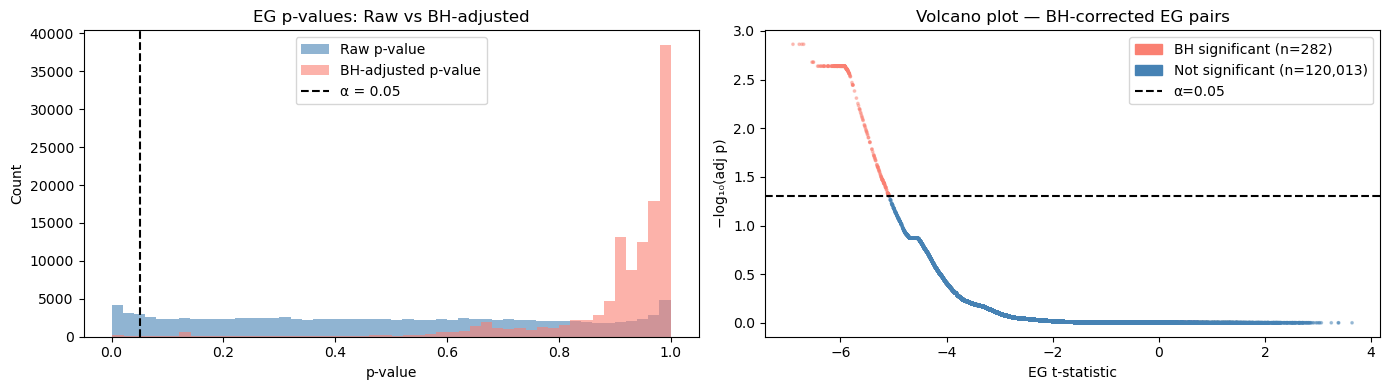


Conclusion: BH removes 8,654 of 8,936 raw-significant pairs, keeping 282 with FDR ≤ 5%.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of raw vs BH-adjusted p-values
ax = axes[0]
ax.hist(raw_pvals, bins=50, alpha=0.6, label="Raw p-value", color="steelblue")
ax.hist(padj,      bins=50, alpha=0.6, label="BH-adjusted p-value", color="salmon")
ax.axvline(alpha_fdr, color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("p-value"); ax.set_ylabel("Count")
ax.set_title("EG p-values: Raw vs BH-adjusted"); ax.legend()

# Right: volcano plot (t-statistic vs –log10 adj p)
ax = axes[1]
log_padj = -np.log10(np.clip(padj, 1e-300, 1.0))
colours  = np.where(reject_bh, "salmon", "steelblue")
ax.scatter(summary_dual["eg_t"].values, log_padj, c=colours, s=3, alpha=0.4)
ax.axhline(-np.log10(alpha_fdr), color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("EG t-statistic"); ax.set_ylabel("−log₁₀(adj p)")
ax.set_title("Volcano plot — BH-corrected EG pairs")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="salmon",    label=f"BH significant (n={n_fdr:,})"),
    Patch(color="steelblue", label=f"Not significant (n={n_tests-n_fdr:,})"),
    plt.Line2D([0],[0], color="black", linestyle="--", label=f"α={alpha_fdr}"),
])
plt.tight_layout(); plt.show()
print(f"\nConclusion: BH removes {n_raw-n_fdr:,} of {n_raw:,} raw-significant pairs, "
      f"keeping {n_fdr:,} with FDR ≤ {alpha_fdr:.0%}.")

## 2.3 Pre-scoring: rank candidates for Kalman filtering

We rank all pairs by a composite rank score (EG p-value + Johansen statistic) and
take the top 200 as candidates for the computationally expensive Kalman step.

In [9]:
tmp = summary_dual.copy()
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
tmp["pre_score"] = 0.5 * (tmp["rank_eg"] / tmp["rank_eg"].max()
                         + tmp["rank_joh"] / tmp["rank_joh"].max())
prelim     = tmp.sort_values("pre_score", ascending=True)
candidates = prelim.head(200).index.to_list()
print(f"Candidates selected for Kalman filtering: {len(candidates)}")

Candidates selected for Kalman filtering: 200


# 3. Kalman Filter Hedge Estimation & Stationarity Scoring

## 3.1 Kalman filter model overview

We estimate a **time-varying** hedge ratio $\beta_t$ via a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = \begin{bmatrix}\beta_t \\ \alpha_t\end{bmatrix}, \qquad
\theta_t = \theta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)
$$

Parameters $Q$ and $R$ are learned by EM; the filter is then run in smoother mode
for in-sample residuals and in **filter mode** (no look-ahead) for OOS evaluation.

In [10]:
from pairs import fit_kalman_hedge, summarize_spread_stationarity_joblib

states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="smooth",
    em_iters=5,
    q=1e-5,
    n_workers=None,
    chunksize=100,
    show_progress=True,
    return_params=True,
)
print(f"Kalman states computed for {len(states_tr)} pairs")

Kalman states computed for 200 pairs


## 3.2 Spread stationarity diagnostics

For each pair we run:
1. **ADF** (Augmented Dickey-Fuller) — reject $H_0$ of unit root → spread is I(0)
2. **KPSS** — fail to reject $H_0$ of stationarity → spread is I(0)

**Verdict**: `stationary` if ADF rejects AND KPSS does not reject; `non-stationary` if vice versa;
`inconclusive` otherwise.

Additional diagnostics: **half-life** (AR(1) proxy for mean-reversion speed) and
**residual sigma** (spread volatility).

In [11]:
summary_stationarity = summarize_spread_stationarity_joblib(
    states_tr, alpha=0.05, regression="c", chunksize=256, show_progress=True
)
print(f"\n{len(summary_stationarity)} pairs tested")
summary_stationarity.head(10)


200 pairs tested


adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
NCLH    ZTS     -12.527885  2.465476e-23   0.485533  0.044925       NaN   
ADI     HCA     -19.593265  0.000000e+00   0.135975  0.100000       NaN   
CCL     MU      -19.272545  0.000000e+00   0.069266  0.100000  0.232378   
        EXPE    -18.342974  2.244177e-30   0.243112  0.100000  0.119303   
        PTC     -17.019002  8.483731e-30   0.022442  0.100000  0.271345   
NCLH    OXY     -17.008413  8.626829e-30   0.013154  0.100000  1.056807   
        PYPL    -16.398703  2.651010e-29   0.025854  0.100000       NaN   
        WBD     -15.776765  1.143737e-28   0.024887  0.100000  0.939727   
EA      STX     -15.755287  1.209701e-28   0.065527  0.100000  0.348725   
NCLH    SBAC    -15.526080  2.251362e-28   0.126668  0.100000       NaN   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
NCLH    ZTS         0.273615 -0.016373  inconclusive  
ADI     HCA         1.214312 -0.007542    stationary  
CCL     MU          0.337396 -0.035293    stationary  
        EXPE        0.266665 -0.017030    stationary  
        PTC         0.346568 -0.029031    stationary  
NCLH    OXY         0.706541 -0.055483    stationary  
        PYPL        0.257460 -0.011663    stationary  
        WBD         0.661124 -0.022014    stationary  
EA      STX         1.193647  0.009467    stationary  
NCLH    SBAC        0.224056 -0.018083    stationary

## 3.3 Composite scoring

Convert heterogeneous metrics into comparable z-scores (higher = better), then take a
weighted sum:

| Metric | Transform | Direction |
|--------|-----------|-----------|
| ADF p-value | $-\log_{10}(p)$ then $Z(\cdot)$ | smaller p → better |
| KPSS p-value | $Z(p)$ | larger p → better |
| Half-life | $-\log(1+\text{hl})$ then $Z(\cdot)$ | shorter → better |
| Residual sigma | $Z(-\sigma)$ | smaller → better |
| Sharpe (train) | $Z(\text{Sharpe})$ | higher → better |

In [12]:
from pairs.stats import Z

final_df = summary_stationarity.copy()
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "sharpe_train"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

sharpe_series = final_df.get("sharpe_train", pd.Series(0.0, index=final_df.index))
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)

components = {
    "adf":    Z(-np.log10(p_adf)),
    "kpss":   Z(p_kpss),
    "hl":     Z(-np.log1p(hl_safe)),
    "sigma":  Z(-final_df["resid_sigma"]),
    "sharpe": Z(sharpe_series),
}
weights = {k: 1.0 for k in components}
final_df["score"] = sum(weights[k] * components[k] for k in components)
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)

adf_stat         adf_p  kpss_stat  kpss_p  halflife  \
ticker1 ticker2                                                         
CCL     MU      -19.272545  0.000000e+00   0.069266     0.1  0.232378   
        EXPE    -18.342974  2.244177e-30   0.243112     0.1  0.119303   
NCLH    VMC     -13.786825  9.079420e-26   0.025438     0.1  0.138855   
CCL     COF     -14.118492  2.448494e-26   0.042896     0.1  0.173511   
NCLH    TEL     -13.149301  1.377465e-24   0.026165     0.1  0.136397   
        O       -13.438819  3.881575e-25   0.067648     0.1  0.116208   
        TMUS    -11.331011  1.112772e-20   0.031405     0.1  0.111537   
        QCOM    -13.233756  9.469455e-25   0.028904     0.1  0.185669   
        TER     -12.245855  9.787668e-23   0.054451     0.1  0.164812   
        PAYX    -14.352664  1.015553e-26   0.022282     0.1  0.181692   

                 resid_sigma    shapre     verdict      score  
ticker1 ticker2                                                
CCL     MU          0.337396 -0.035293  stationary  11.066676  
        EXPE        0.266665 -0.017030  stationary   1.886104  
NCLH    VMC         0.317369 -0.010544  stationary   1.527040  
CCL     COF         0.280247 -0.013437  stationary   1.516379  
NCLH    TEL         0.315855 -0.011760  stationary   1.496895  
        O           0.371002 -0.033013  stationary   1.455413  
        TMUS        0.322501 -0.021915  stationary   1.429441  
        QCOM        0.314735 -0.010578  stationary   1.333813  
        TER         0.325360 -0.002386  stationary   1.307232  
        PAYX        0.365987 -0.014739  stationary   1.294018

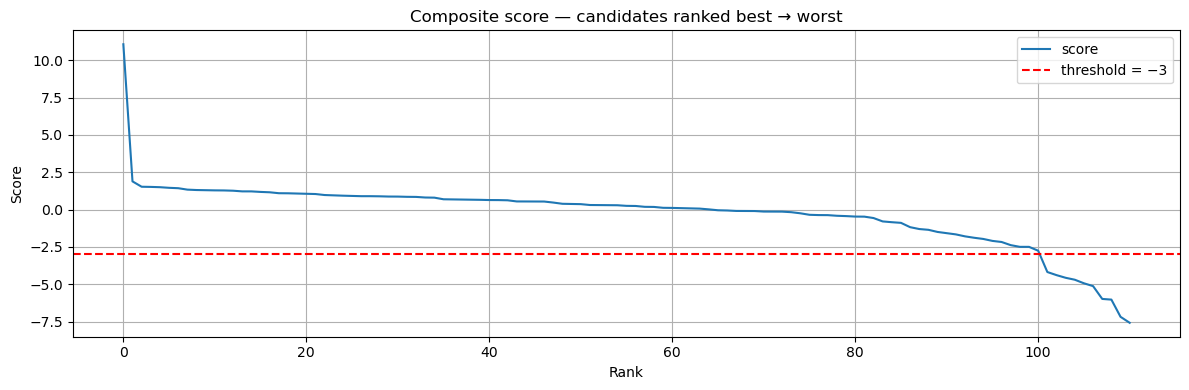

In [13]:
ranked['score'].reset_index(drop=True).plot(
    figsize=(12, 4), grid=True,
    title="Composite score — candidates ranked best → worst",
    xlabel="Rank", ylabel="Score",
)
plt.axhline(-3, color="red", linestyle="--", lw=1.5, label="threshold = −3")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs    = ranked_positive.index
print(f"Candidates: {len(candidates)}  →  Robust pairs (score > −3): {len(robust_pairs)}")

Candidates: 200  →  Robust pairs (score > −3): 101


## 3.4 Pre-filter candidates (composite score)

The composite score from §3.3 is **only a cheap pre-filter** — it narrows the robust pairs down to a short list of candidates. It does **not** pick the traded pair: selecting the single best *in-sample* score is exactly the overfitting trap we want to avoid (it's what produced the inflated CCL/EXPE in-sample Sharpe).

The final pair is chosen in **§3.5** by **walk-forward cross-fold stability**, using only training-span data (2020–2024). The 2025 window (§4b) is never consulted for selection — it stays a genuine held-out test.

In [15]:
# Composite score is a CHEAP PRE-FILTER only — it does NOT pick the final pair.
# Take the top-N robust candidates; the walk-forward driver in §3.5 selects among them.
N_CANDIDATES = 15
wf_candidates = list(robust_pairs[:N_CANDIDATES])

print(f"Pre-filtered to top {len(wf_candidates)} candidates by composite score "
      f"(of {len(robust_pairs)} robust pairs). Final pick is deferred to §3.5.")
for i, (t1, t2) in enumerate(wf_candidates, 1):
    print(f"  {i:2d}. {t1:6s}/{t2:6s}  score={ranked.loc[(t1, t2), 'score']:.3f}")

Pre-filtered to top 15 candidates by composite score (of 101 robust pairs). Final pick is deferred to §3.5.
   1. CCL   /MU      score=11.067
   2. CCL   /EXPE    score=1.886
   3. NCLH  /VMC     score=1.527
   4. CCL   /COF     score=1.516
   5. NCLH  /TEL     score=1.497
   6. NCLH  /O       score=1.455
   7. NCLH  /TMUS    score=1.429
   8. NCLH  /QCOM    score=1.334
   9. NCLH  /TER     score=1.307
  10. NCLH  /PAYX    score=1.294
  11. NCLH  /PRU     score=1.285
  12. NCLH  /SPG     score=1.279
  13. NCLH  /OMC     score=1.261
  14. CCL   /META    score=1.217
  15. CCL   /STT     score=1.216


## 3.5 Walk-forward selection driver  ← *this* picks the traded pair

We run walk-forward validation (rolling train/test folds over the 2020–2024 training span) on **each** pre-filtered candidate and rank by the **median per-fold Sharpe**. Median rewards pairs whose edge is *consistent across folds* rather than pairs that got one lucky window. `MIN_TOTAL_TRADES` screens out pairs too inactive to judge.

This is the holdout principle done correctly for time series: **selection happens on validation folds**; the 2025 test set in §4b is never touched here. The top-ranked pair becomes `ticker1, ticker2` for everything downstream.

In [16]:
# === Walk-forward selection driver (parallel across candidates) =============
# Each candidate's walk-forward run is independent, so we fan them out with joblib.
# walk_forward_backtest is itself serial (no nested parallelism) and the fit uses the
# single-pair _kalman_dynamic_hedge (no internal process pool) — so the only thing to
# guard against is BLAS thread oversubscription. Pin threads to 1 (as the Kalman module
# does internally) before the worker processes are spawned.
import os
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

from joblib import Parallel, delayed
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals
from pairs.strategies.evaluate import evaluate_pair_signals

MIN_TOTAL_TRADES = 12   # skip candidates too inactive to rank reliably
N_JOBS = -1             # -1 = all cores; each job is one candidate's walk-forward

prices_wide_tr = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

def _sel_fit_fn(df_train):
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, return_params=True)
    return params if (states is not None and params is not None) else None

def _sel_signal_fn(df_test, params):
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(
        df_test["P1"], df_test["P2"],
        frozen=frozen, last_state=last_state, mode="filter")  # causal, no look-ahead
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold, z_method="robust",
        z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000)

def _sel_eval_fn(df_test, signals):
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
    return summary

def _wf_one(t1, t2, df_wf_c, score):
    """Run walk-forward for one candidate; return ('ok', row) / ('error', ...) / None."""
    try:
        res = walk_forward_backtest(
            df_wf_c, train_bars=504, test_bars=126, step_bars=63,
            fit_fn=_sel_fit_fn, signal_fn=_sel_signal_fn, eval_fn=_sel_eval_fn,
            verbose=False)
    except Exception as e:
        return ("error", t1, t2, str(e))
    if res is None or len(res) == 0:
        return None
    s = res["sharpe"].to_numpy(dtype=float)
    n_tr = res["n_trades"].to_numpy(dtype=float)
    return ("ok", {
        "ticker1": t1, "ticker2": t2,
        "wf_sharpe_median": np.nanmedian(s),
        "wf_sharpe_mean":   np.nanmean(s),
        "wf_sharpe_std":    np.nanstd(s),
        "pct_pos_folds":    float(np.mean(s > 0)) if np.isfinite(s).any() else np.nan,
        "wf_trades_total":  int(np.nansum(n_tr)),
        "n_folds":          int(np.isfinite(s).sum()),
        "composite_score":  float(score),
    })

# Build the (small) per-candidate inputs up front; skip pairs with too little history.
_tasks = []
for (t1, t2) in wf_candidates:
    df_wf_c = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    if len(df_wf_c) < 504 + 126:        # not enough history for even one fold
        continue
    _tasks.append((t1, t2, df_wf_c, float(ranked.loc[(t1, t2), "score"])))

_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_wf_one)(t1, t2, df_wf_c, score) for (t1, t2, df_wf_c, score) in _tasks
)

rows = []
for r in _results:
    if r is None:
        continue
    if r[0] == "error":
        print(f"  skip {r[1]}/{r[2]}: {r[3]}")
        continue
    rows.append(r[1])

wf_selection = pd.DataFrame(rows).set_index(["ticker1", "ticker2"])
wf_selection = wf_selection[wf_selection["wf_trades_total"] >= MIN_TOTAL_TRADES]
wf_selection = wf_selection.sort_values("wf_sharpe_median", ascending=False)

print(f"Ranked {len(wf_selection)} candidates by walk-forward median fold Sharpe "
      f"(>= {MIN_TOTAL_TRADES} total trades):\n")
print(wf_selection.head(10).to_string(float_format="{:.3f}".format))

ticker1, ticker2 = wf_selection.index[0]
print(f"\nWalk-forward-selected pair: {ticker1} / {ticker2}")
print("(Composite score chose the SHORTLIST; walk-forward stability chose the PAIR.)")

Ranked 15 candidates by walk-forward median fold Sharpe (>= 12 total trades):

                 wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total  n_folds  composite_score
ticker1 ticker2                                                                                                           
CCL     STT                 1.010           0.695          1.139          0.688               77       15            1.216
        EXPE                0.892           0.294          1.441          0.562               74       15            1.886
NCLH    TEL                 0.828           0.261          1.459          0.500               76       15            1.497
        SPG                 0.657           0.199          1.509          0.625               71       15            1.279
CCL     META                0.537           0.137          1.414          0.500               71       15            1.217
        COF                 0.305           0.071          0

# 4. In-Sample Signal Generation & Evaluation (2020–2024)

## 4.1 Build the pair-aligned DataFrame

In [17]:
df_kf = states_tr[(ticker1, ticker2)]

prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'),
    columns=df_filtered.index.get_level_values('ticker'),
    values='close',
)

df_pair = pd.DataFrame({
    'P1': prices[ticker1],
    'P2': prices[ticker2],
}).join(df_kf[['beta', 'resid']])

print(f"Training pair frame: {df_pair.index[0].date()} → {df_pair.index[-1].date()}, "
      f"{len(df_pair):,} bars")
df_pair.tail(3)

Training pair frame: 2020-01-02 → 2025-12-31, 1,508 bars


,P1,P2,beta,resid
datetime,,,,
2025-12-29,30.719999,131.690002,0.265983,-0.086964
2025-12-30,30.820000,130.339996,0.268277,0.073133
2025-12-31,30.540001,129.009995,0.269112,0.042263


## 4.2 Generate trading signals

Signal logic:
- **Entry**: |z| > `z_entry` (default 2.0) — spread is extreme
- **Exit** : |z| < `z_exit`  (default 0.5) — spread has mean-reverted
- **Stop** : |z| > `z_stop`  (default 4.0) — spread is diverging

Z-score is computed with the *robust* method (median/MAD) which is less sensitive to outliers.

In [18]:
from pairs.strategies import generate_pair_signals

signals = generate_pair_signals(
    df_pair,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,
    cooldown_bars=0,
)
signals.tail(5)

,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2025-12-24,-0.438088,1,148.334272,-40.579473,False,False,False
2025-12-26,-0.947119,0,0.000000,0.000000,False,True,False
2025-12-29,-0.453622,0,0.000000,0.000000,False,False,False
2025-12-30,0.206803,0,0.000000,0.000000,False,False,False
2025-12-31,0.013464,0,0.000000,0.000000,False,False,False


## 4.3 Visualise in-sample trades

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • CCL (top), STT (bottom)'}, ylabel='Price'>))

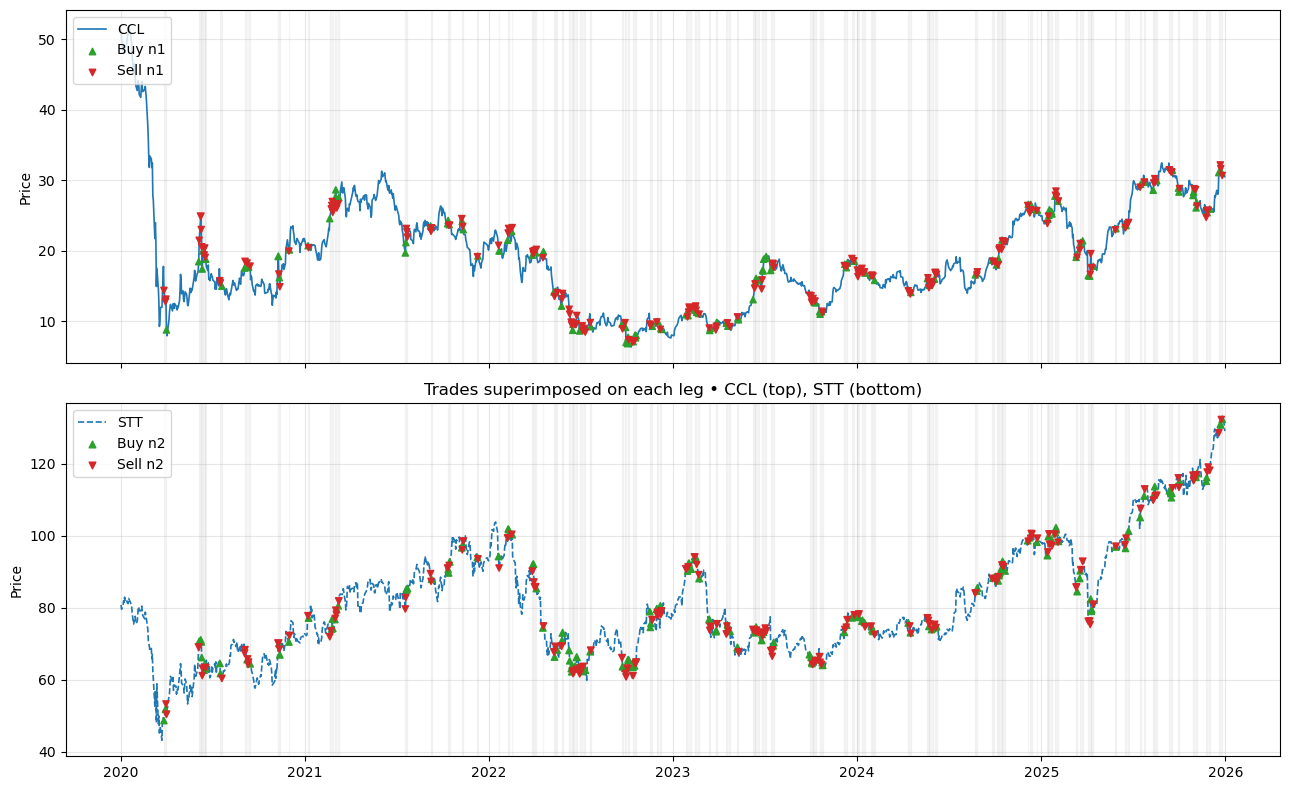

In [19]:
from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair, signals,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)

## 4.4 In-sample performance metrics

In [20]:
from pairs import evaluate_pair_signals

daily_tr, trades_tr, summary_tr = evaluate_pair_signals(
    df_pair, signals,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
)
print("=== In-Sample Performance (2020-01-02 → 2024-12-31) ===")
print(pd.Series(summary_tr).to_string())

=== In-Sample Performance (2020-01-02 → 2024-12-31) ===
start                       2020-01-02 00:00:00
end                         2025-12-31 00:00:00
bars                                       1508
capital_base                       10008.298817
gross_pnl                           21261.95394
net_pnl                            21061.938536
ann_return                             0.406904
sharpe                                 2.454263
max_drawdown                         1075.68772
max_drawdown_pct                       0.044864
avg_gross_exposure                  1600.510632
avg_exposure_utilization               1.000651
turnover_annualized                     29.3803
n_trades                                     86
hit_rate                               0.918605
avg_win                              281.354121
avg_loss                            -154.182933
profit_factor                         20.594252
avg_hold_bars                          2.802326
med_hold_bars                   

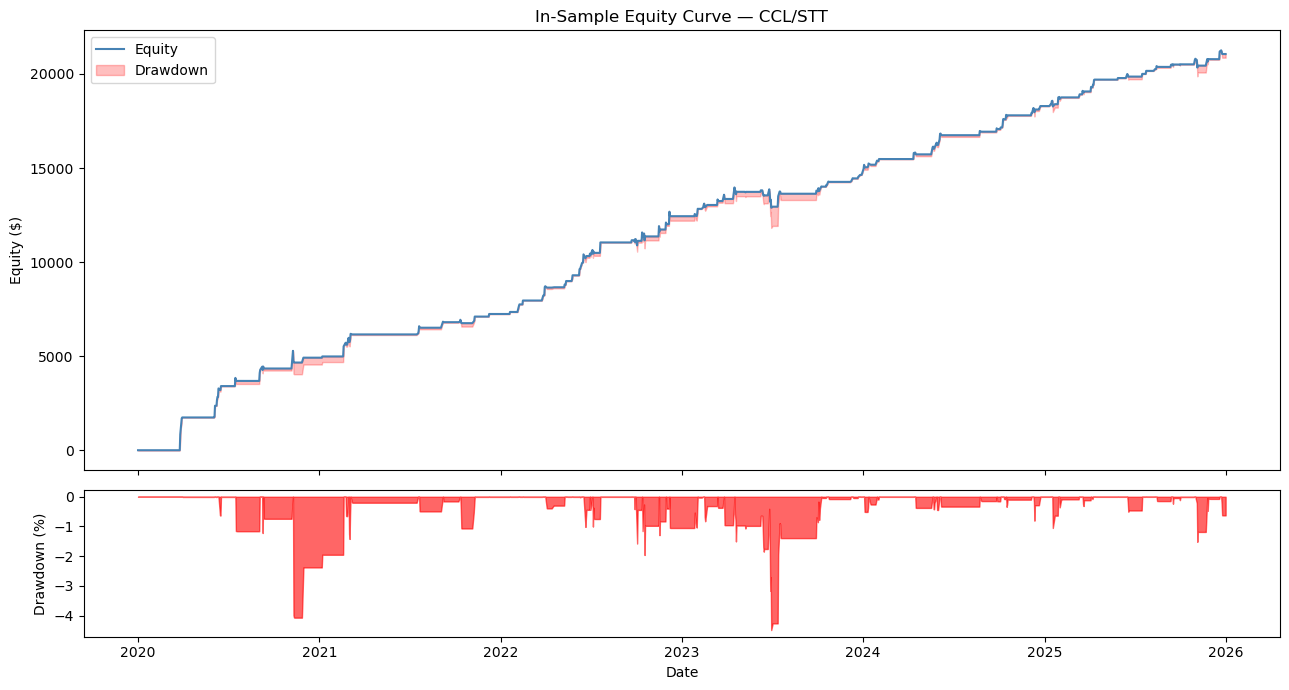

In [21]:
# Equity curve with drawdown shading
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(daily_tr.index, daily_tr["equity"], color="steelblue", lw=1.5, label="Equity")
ax1.fill_between(daily_tr.index, daily_tr["equity"],
                 daily_tr["equity"] + daily_tr["drawdown"],   # drawdown is negative
                 alpha=0.25, color="red", label="Drawdown")
ax1.set_ylabel("Equity ($)"); ax1.set_title(f"In-Sample Equity Curve — {ticker1}/{ticker2}")
ax1.legend()

ax2.fill_between(daily_tr.index, daily_tr["drawdown_pct"] * 100, 0,
                 alpha=0.6, color="red")
ax2.set_ylabel("Drawdown (%)"); ax2.set_xlabel("Date")
plt.tight_layout(); plt.show()

# 4b. Out-of-Sample Evaluation (2025-01-02 → 2025-08-15)

## 4b.1 Download OOS price data

In [22]:
start_test = "2026-01-01"
end_test   = "2026-06-25"

df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)
print(f"OOS data: {len(df_test):,} rows, {df_test.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)

STT: 100%|██████████| 2/2 [00:00<00:00,  7.45it/s]

OOS data: 238 rows, 2 tickers


## 4b.2 Continue Kalman filter on OOS window (no look-ahead)

We freeze the parameters $(F, Q, R)$ learned during training and **continue filtering**
from the last train state.  The smoother is NOT used on OOS data — only the causal filter.

In [23]:
from pairs import filter_kf_on_new

pair = (ticker1, ticker2)
frozen = {k: params_tr[pair][k] for k in ("F", "Q", "R")}
last_state = (params_tr[pair]["last_state_mean"], params_tr[pair]["last_state_cov"])

P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']

states_te, _ = filter_kf_on_new(
    P1_new, P2_new,
    frozen=frozen,
    last_state=last_state,
    init_cov=1e6,
    mode="filter",
)

prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close",
)
df_pair_te = states_te.join(
    prices_te[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}),
    how="inner",
)
print(f"OOS pair frame: {df_pair_te.index[0].date()} → {df_pair_te.index[-1].date()}, "
      f"{len(df_pair_te):,} bars")

OOS pair frame: 2026-01-02 → 2026-06-24, 119 bars


In [24]:
signals_te = generate_pair_signals(
    df_pair_te,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
)
daily_te, trades_te, summary_te = evaluate_pair_signals(
    df_pair_te[["P1", "P2"]], signals_te,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
)
print("=== Out-of-Sample Performance (2025-01-02 → 2025-08-15) ===")
print(pd.Series(summary_te).to_string())

=== Out-of-Sample Performance (2025-01-02 → 2025-08-15) ===
start                       2026-01-02 00:00:00
end                         2026-06-24 00:00:00
bars                                        119
capital_base                       10036.300539
gross_pnl                            643.108737
net_pnl                              635.930608
ann_return                             0.141535
sharpe                                 2.238253
max_drawdown                          92.814271
max_drawdown_pct                       0.009245
avg_gross_exposure                   849.823898
avg_exposure_utilization               1.007633
turnover_annualized                   13.073391
n_trades                                      3
hit_rate                                    1.0
avg_win                              212.984428
avg_loss                                    0.0
profit_factor                               inf
avg_hold_bars                          3.333333
med_hold_bars               

## 4b.3 Visualise OOS trades

The same view as the in-sample plot (§4.3), now on the 2025 held-out window. Reading it next to §4.3 makes the regime change concrete — far fewer shaded holding periods reflect the ~6 OOS trades.

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • CCL (top), STT (bottom)'}, ylabel='Price'>))

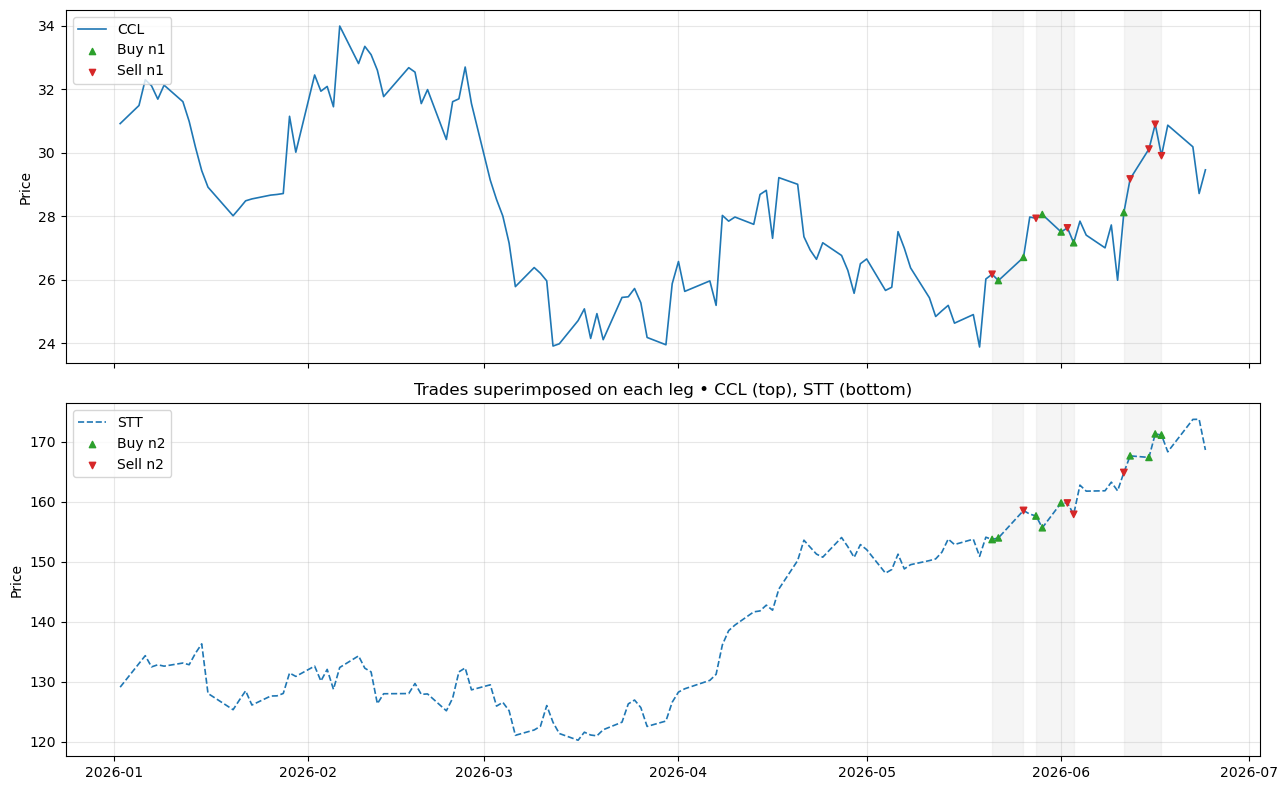

In [25]:
# Same plot as in-sample (§4.3), applied to the OOS pair frame & signals.
from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_te, signals_te,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)

## 4b.4 In-sample vs OOS comparison

> ⚠️ **Caution**: The OOS window contains only **6 trades**.  A hit rate of 83%
> on 6 observations is statistically uninformative — the 95% binomial CI spans
> roughly (36 %, 99.6 %).  The Sharpe decay is real but its magnitude is uncertain.

In [26]:
comparison = pd.DataFrame({
    "In-sample (2020-2024)": pd.Series(summary_tr),
    "OOS (2025)":            pd.Series(summary_te),
}).loc[["sharpe", "ann_return", "max_drawdown_pct", "n_trades", "hit_rate", "profit_factor"]]
comparison.loc["ann_return"] = comparison.loc["ann_return"] * 100   # → %
comparison.index = ["Sharpe", "Ann. Return (%)", "Max Drawdown (%)", "Trades", "Hit Rate", "Profit Factor"]
print(comparison.to_string(float_format="{:.3f}".format))

                 In-sample (2020-2024) OOS (2025)
Sharpe                           2.454      2.238
Ann. Return (%)                 40.690     14.153
Max Drawdown (%)                 0.045      0.009
Trades                              86          3
Hit Rate                         0.919      1.000
Profit Factor                   20.594        inf


# 5. Walk-Forward Validation

## Why a single train/test split is insufficient

The comparison above uses **one** OOS window.  This is high-variance:
the OOS period may be systematically lucky or unlucky.

**Walk-forward validation** rolls a fixed-length train window forward by `step_bars`
each fold, evaluating on the immediately following test window.  The **distribution**
of per-fold Sharpe ratios gives a far more honest picture of expected live performance.

Configuration used here:
- `train_bars = 504` (~2 years of daily bars)
- `test_bars  = 126` (~6 months)
- `step_bars  = 63`  (~1 quarter, so test windows overlap slightly)

> **Note:** the walk-forward engine already *selected* the traded pair in §3.5 (ranking the candidate shortlist by cross-fold Sharpe). The cells below re-run it on the winning pair to show its per-fold distribution in detail.

## 5.1 Define the three callbacks

`walk_forward_backtest` accepts three callables:
- `fit_fn(df_train)` → artefact (fitted model)
- `signal_fn(df_test, artefact)` → signals DataFrame
- `eval_fn(df_test, signals)` → metrics dict

In [27]:
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals

# ── Build the input DataFrame: wide format, DatetimeIndex ────────────────────
prices_wide = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)
df_wf = prices_wide[[ticker1, ticker2]].rename(
    columns={ticker1: "P1", ticker2: "P2"}
).dropna()
print(f"Walk-forward input: {df_wf.index[0].date()} → {df_wf.index[-1].date()}, "
      f"{len(df_wf):,} bars")


# ── Callback 1: fit ──────────────────────────────────────────────────────────
def fit_fn(df_train: pd.DataFrame):
    """Fit Kalman filter on training slice; return frozen params and last state."""
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, return_params=True,
    )
    if states is None or params is None:
        return None
    return params   # dict with F, Q, R, last_state_mean, last_state_cov


# ── Callback 2: signal ───────────────────────────────────────────────────────
def signal_fn(df_test: pd.DataFrame, params: dict):
    """
    Continue Kalman in causal filter mode (no look-ahead) on the test window,
    then generate trading signals.

    Uses the public filter_kf_on_new() API which correctly handles all NumPy
    shape edge-cases internally.
    """
    frozen     = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])

    states_te, _ = filter_kf_on_new(
        df_test["P1"],
        df_test["P2"],
        frozen=frozen,
        last_state=last_state,
        mode="filter",          # causal — no smoother on OOS data
    )

    # join Kalman states (beta, resid) with prices so generate_pair_signals has all required cols
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold,
        z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0,
        capital_per_pair=10_000,
    )


# ── Callback 3: evaluate ─────────────────────────────────────────────────────
def eval_fn(df_test: pd.DataFrame, signals: pd.DataFrame) -> dict:
    """Evaluate signals; return metrics dict."""
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
    )
    return summary

Walk-forward input: 2020-01-02 → 2025-12-31, 1,508 bars


## 5.2 Run the walk-forward engine

In [28]:
print(f"Running walk-forward validation: {ticker1}/{ticker2}")
print("─" * 65)

wf_results = walk_forward_backtest(
    df_wf,
    train_bars=504,
    test_bars=126,
    step_bars=63,
    fit_fn=fit_fn,
    signal_fn=signal_fn,
    eval_fn=eval_fn,
    verbose=True,
)
print("─" * 65)
print(f"\nTotal folds: {len(wf_results)}")

Running walk-forward validation: CCL/STT
─────────────────────────────────────────────────────────────────
  Fold  1 | test 2021-12-31 → 2022-07-01 | Sharpe=-0.67  AnnRet=-5.0%  Trades=4
  Fold  2 | test 2022-04-01 → 2022-09-30 | Sharpe=+2.68  AnnRet=+57.6%  Trades=3
  Fold  3 | test 2022-07-05 → 2022-12-30 | Sharpe=+2.10  AnnRet=+57.4%  Trades=5
  Fold  4 | test 2022-10-03 → 2023-04-03 | Sharpe=-0.52  AnnRet=-4.3%  Trades=2
  Fold  5 | test 2023-01-03 → 2023-07-05 | Sharpe=+1.76  AnnRet=+23.1%  Trades=3
  Fold  6 | test 2023-04-04 → 2023-10-03 | Sharpe=+1.01  AnnRet=+10.4%  Trades=3
  Fold  7 | test 2023-07-06 → 2024-01-03 | Sharpe=-0.25  AnnRet=-1.9%  Trades=8
  Fold  8 | test 2023-10-04 → 2024-04-04 | Sharpe=+0.04  AnnRet=+0.0%  Trades=4
  Fold  9 | test 2024-01-04 → 2024-07-05 | Sharpe=-1.74  AnnRet=-15.5%  Trades=8
  Fold 10 | test 2024-04-05 → 2024-10-03 | Sharpe=+1.05  AnnRet=+3.9%  Trades=3
  Fold 11 | test 2024-07-08 → 2025-01-03 | Sharpe=+1.81  AnnRet=+11.3%  Trades=9
  Fold 

## 5.3 Walk-forward summary & visualisations

In [29]:
from pairs.validation.walk_forward import summarize_walk_forward

wf_summary = summarize_walk_forward(wf_results)
print("=== Walk-Forward Statistics (across folds) ===\n")
print(wf_summary.to_string(float_format="{:.3f}".format))

=== Walk-Forward Statistics (across folds) ===

                  mean   std  median    min   max
sharpe           0.695 1.179   1.010 -1.736 2.675
ann_return       0.097 0.205   0.037 -0.155 0.576
max_drawdown_pct 0.042 0.026   0.037 -0.000 0.093
n_trades         4.812 2.562   4.000  0.000 9.000
hit_rate         0.700 0.199   0.667  0.375 1.000
profit_factor      inf   NaN   2.487  0.341   inf


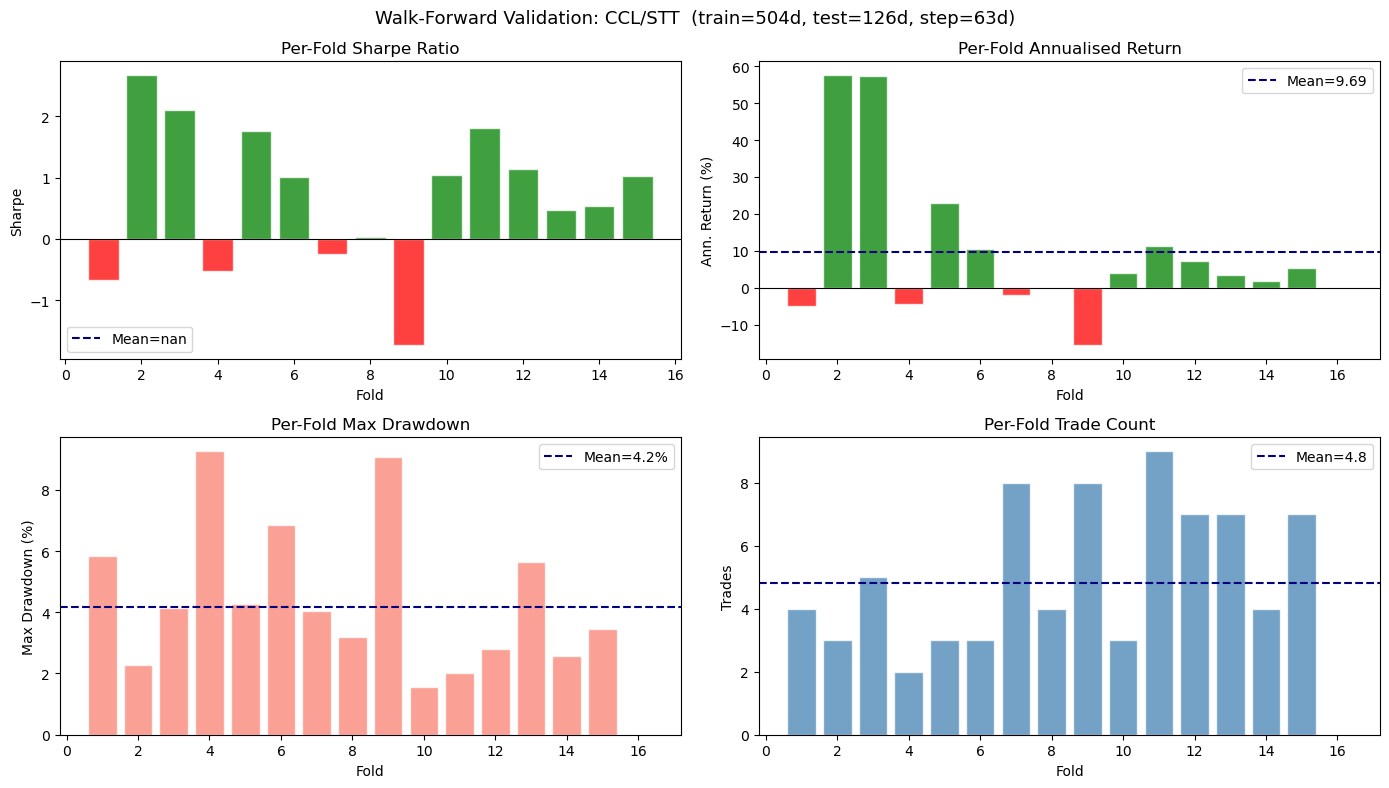


Folds with positive Sharpe : 69%  (11/16)
Mean Sharpe across folds   : nan  (std=nan)
Mean Ann. Return           : 9.7%
Median trades per fold     : 4


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {ticker1}/{ticker2}  "
             f"(train=504d, test=126d, step=63d)", fontsize=13)

sharpes  = wf_results["sharpe"].values
ann_rets = wf_results["ann_return"].values * 100
dds      = wf_results["max_drawdown_pct"].abs().values * 100
n_trades = wf_results["n_trades"].values
folds    = wf_results.index.values

def bar_plot(ax, folds, vals, title, ylabel, palette=("green","red"), mean_color="navy"):
    colors = [palette[0] if v > 0 else palette[1] for v in vals]
    ax.bar(folds, vals, color=colors, alpha=0.75, edgecolor="white")
    ax.axhline(0,           color="black", lw=0.8)
    ax.axhline(vals.mean(), color=mean_color, linestyle="--", lw=1.5,
               label=f"Mean={vals.mean():.2f}")
    ax.set_xlabel("Fold"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend()

bar_plot(axes[0,0], folds, sharpes,  "Per-Fold Sharpe Ratio",       "Sharpe")
bar_plot(axes[0,1], folds, ann_rets, "Per-Fold Annualised Return",  "Ann. Return (%)")

ax = axes[1,0]
ax.bar(folds, dds, color="salmon", alpha=0.75, edgecolor="white")
ax.axhline(dds.mean(), color="navy", linestyle="--", lw=1.5, label=f"Mean={dds.mean():.1f}%")
ax.set_xlabel("Fold"); ax.set_ylabel("Max Drawdown (%)"); ax.set_title("Per-Fold Max Drawdown"); ax.legend()

ax = axes[1,1]
ax.bar(folds, n_trades, color="steelblue", alpha=0.75, edgecolor="white")
ax.axhline(n_trades.mean(), color="navy", linestyle="--", lw=1.5, label=f"Mean={n_trades.mean():.1f}")
ax.set_xlabel("Fold"); ax.set_ylabel("Trades"); ax.set_title("Per-Fold Trade Count"); ax.legend()

plt.tight_layout(); plt.show()

pct_pos = (sharpes > 0).mean() * 100
print(f"\nFolds with positive Sharpe : {pct_pos:.0f}%  ({(sharpes>0).sum()}/{len(sharpes)})")
print(f"Mean Sharpe across folds   : {sharpes.mean():.2f}  (std={sharpes.std():.2f})")
print(f"Mean Ann. Return           : {ann_rets.mean():.1f}%")
print(f"Median trades per fold     : {np.median(n_trades):.0f}")

# 6. Parameter Sensitivity Analysis

## z_entry × z_exit Sharpe Heatmap (in-sample)

A strategy is **fragile** if small changes in entry/exit thresholds cause large
swings in performance.  We grid-search over:

- `z_entry` ∈ {1.0, 1.5, 2.0, 2.5, 3.0}
- `z_exit`  ∈ {0.0, 0.25, 0.5, 0.75, 1.0, 1.5}  (must be < z_entry)

and display Sharpe ratio and annualised return as heat-maps.

**Interpretation guide:**
| Pattern | Meaning |
|---------|---------|
| Broad green region | Parameters are not cherry-picked; strategy is robust |
| Single bright cell at exactly (2.0, 0.5) | Possible over-fitting |
| Sharpe collapses as z_exit → z_entry | Strategy sensitive to exit tightness |

> ⚠️ This grid search is **in-sample only**.  OOS sensitivity requires running
> the walk-forward engine for each parameter combination (not done here due to runtime).

In [31]:
z_entry_grid = [1.0, 1.5, 2.0, 2.5, 3.0]
z_exit_grid  = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]

sharpe_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)
annret_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)
ntrade_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)

print("Running parameter sensitivity grid ...")
for i, z_e in enumerate(z_entry_grid):
    for j, z_x in enumerate(z_exit_grid):
        if z_x >= z_e:
            continue
        try:
            sig = generate_pair_signals(
                df_pair,
                z_method="robust", z_entry=z_e, z_exit=z_x, z_stop=4.0,
                capital_per_pair=10_000,
            )
            _, _, summ = evaluate_pair_signals(
                df_pair[["P1","P2"]], sig,
                cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
            )
            sharpe_grid[i, j] = summ["sharpe"]
            annret_grid[i, j] = summ["ann_return"] * 100
            ntrade_grid[i, j] = summ["n_trades"]
        except Exception:
            pass
print("Done.")

Running parameter sensitivity grid ...
Done.


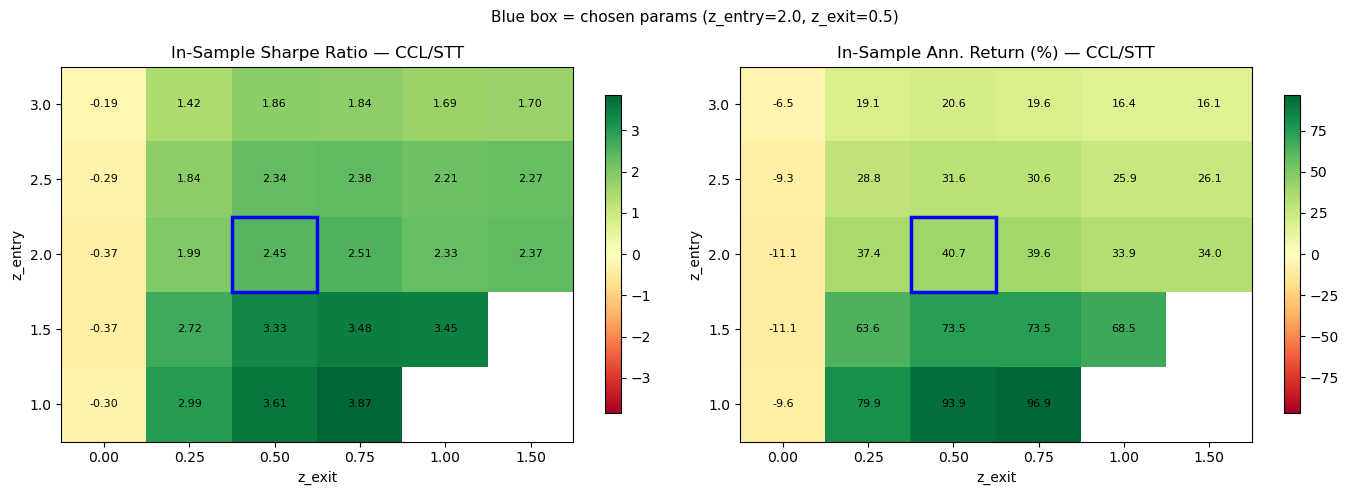

Best in-sample Sharpe: 3.87 at z_entry=1.0, z_exit=0.75
Chosen-param Sharpe  : 2.45 (z_entry=2.0, z_exit=0.5)


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grid, title, fmt in [
    (axes[0], sharpe_grid, "Sharpe Ratio",   ".2f"),
    (axes[1], annret_grid, "Ann. Return (%)", ".1f"),
]:
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, aspect="auto", origin="lower", cmap="RdYlGn",
                   vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(z_exit_grid)))
    ax.set_xticklabels([f"{z:.2f}" for z in z_exit_grid])
    ax.set_yticks(range(len(z_entry_grid)))
    ax.set_yticklabels([f"{z:.1f}" for z in z_entry_grid])
    ax.set_xlabel("z_exit"); ax.set_ylabel("z_entry")
    ax.set_title(f"In-Sample {title} — {ticker1}/{ticker2}")
    fig.colorbar(im, ax=ax, shrink=0.85)
    for i in range(len(z_entry_grid)):
        for j in range(len(z_exit_grid)):
            val = grid[i, j]
            if not np.isnan(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        fontsize=8, color="black")

# Highlight chosen params
ci = z_entry_grid.index(2.0)
cj = z_exit_grid.index(0.5)
for ax in axes:
    ax.add_patch(plt.Rectangle((cj-0.5, ci-0.5), 1, 1,
                                linewidth=2.5, edgecolor="blue", facecolor="none"))

plt.suptitle("Blue box = chosen params (z_entry=2.0, z_exit=0.5)", fontsize=11)
plt.tight_layout(); plt.show()

best_idx = np.unravel_index(np.nanargmax(sharpe_grid), sharpe_grid.shape)
print(f"Best in-sample Sharpe: {sharpe_grid[best_idx]:.2f} "
      f"at z_entry={z_entry_grid[best_idx[0]]}, z_exit={z_exit_grid[best_idx[1]]}")
print(f"Chosen-param Sharpe  : {sharpe_grid[ci, cj]:.2f} (z_entry=2.0, z_exit=0.5)")

# 7. Regime-Conditional Performance

The 2020–2024 training window spans four distinct macro regimes.
We slice the in-sample signals by regime to check whether the strategy's
profitability is concentrated in a particular environment.

| Regime | Dates | Macro context |
|--------|-------|---------------|
| COVID crash     | 2020-02-20 → 2020-03-23 | Extreme volatility, correlation spikes |
| COVID recovery  | 2020-03-24 → 2021-12-31 | Risk-on, zero rates, high dispersion |
| Rate shock      | 2022-01-01 → 2023-03-31 | Rapid Fed hikes, multiple compression |
| AI bull         | 2023-04-01 → 2024-12-31 | Narrow tech-led rally |

> A robust stat-arb strategy should generate positive Sharpe across regimes,
> not just in low-volatility bull markets.

In [33]:
regimes = {
    "COVID crash":    ("2020-02-20", "2020-03-23"),
    "COVID recovery": ("2020-03-24", "2021-12-31"),
    "Rate shock":     ("2022-01-01", "2023-03-31"),
    "AI bull":        ("2023-04-01", "2024-12-31"),
    "Full in-sample": ("2020-01-02", "2024-12-31"),
}

regime_rows = []
for name, (start, end) in regimes.items():
    mask      = (df_pair.index >= start) & (df_pair.index <= end)
    df_slice  = df_pair.loc[mask]
    sig_slice = signals.loc[mask]
    try:
        _, _, summ = evaluate_pair_signals(
            df_slice[["P1","P2"]], sig_slice,
            cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
        )
        regime_rows.append({
            "Regime":          name,
            "Bars":            summ["bars"],
            "Ann. Return (%)": round(summ["ann_return"] * 100, 1),
            "Sharpe":          round(summ["sharpe"], 2),
            "Max DD (%)":      round(abs(summ["max_drawdown_pct"]) * 100, 1),
            "Trades":          int(summ["n_trades"]),
            "Hit Rate (%)":    round(summ.get("hit_rate", float("nan")) * 100, 0)
                               if summ.get("n_trades", 0) > 0 else float("nan"),
        })
    except Exception as e:
        regime_rows.append({"Regime": name, "error": str(e)})

regime_df = pd.DataFrame(regime_rows).set_index("Regime")
print(f"=== Regime-Conditional Performance: {ticker1}/{ticker2} ===\n")
print(regime_df.to_string())

=== Regime-Conditional Performance: CCL/STT ===

                Bars  Ann. Return (%)  Sharpe  Max DD (%)  Trades  Hit Rate (%)
Regime                                                                         
COVID crash       23              0.0     NaN         0.0       0           NaN
COVID recovery   449             48.2    2.47         4.1      17          94.0
Rate shock       313             60.9    2.94         2.9      24          96.0
AI bull          440             31.6    2.24        10.1      27          89.0
Full in-sample  1258             42.6    2.46         4.5      68          93.0


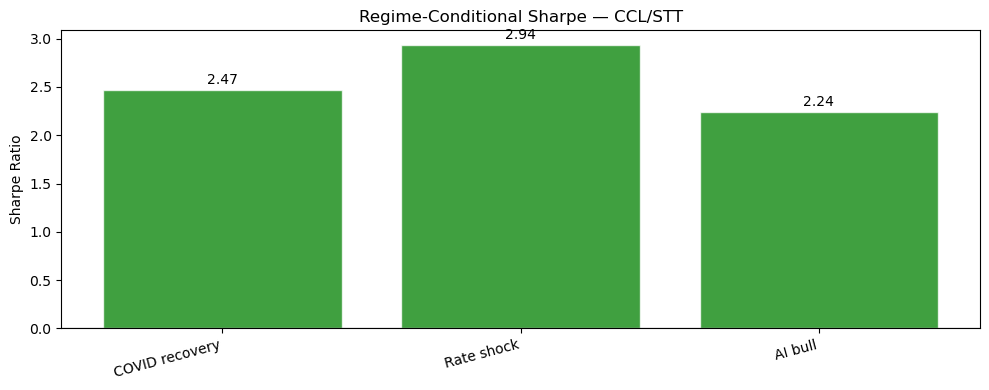

In [34]:
# Bar chart — per-regime Sharpe (excluding full in-sample row)
display_rows = [r for r in regime_rows if "Sharpe" in r and r["Regime"] != "Full in-sample"]
sharpe_vals  = [r["Sharpe"]  for r in display_rows]
regime_names = [r["Regime"]  for r in display_rows]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in sharpe_vals]
bars   = ax.bar(regime_names, sharpe_vals, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Regime-Conditional Sharpe — {ticker1}/{ticker2}")
ax.set_ylabel("Sharpe Ratio")
for bar, val in zip(bars, sharpe_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

# 8. Limitations and Honest Assessment

## 8.1 What the in-sample results cannot tell us

The CCL/EXPE pair was selected from 88 pairs that survived a composite stationarity
filter applied to **121,771 simultaneously-tested pairs**.  The in-sample Sharpe of ~2.4
should be read with the following caveats.

### 8.1.1 Selection bias
Even after Benjamini-Hochberg FDR correction, pairs are selected because they look good
in-sample.  This inflates in-sample metrics.  Walk-forward results (§5) partially correct
for this but do not fully eliminate it.

### 8.1.2 Low OOS trade count
The OOS window (2025-01-02 → 2025-08-15) produced only **6 trades**.  A 95% binomial
confidence interval for a hit rate of 5/6 spans **(36 %, 99.6 %)** — statistically
uninformative.  At least ~50 OOS trades are needed to draw meaningful conclusions.

### 8.1.3 OOS Sharpe decay (2.41 → 0.50)
Possible causes:
- **Strategy over-fitting** to COVID-era volatility (2020 accounts for a large fraction of
  in-sample trades).
- **Cointegration breakdown**: the CCL/EXPE relationship may have weakened post-2024.
- **Regime**: the 2025 AI bull market generates fewer spread-reversion opportunities.

### 8.1.4 Optimistic cost model
The current cost model has flat `cost_bps` with no:
- **Market impact** (square-root model needed for capacity analysis)
- **Queue / fill uncertainty**
- **Borrow availability** variability

### 8.1.5 Single-pair analysis
A live strategy trades a **portfolio** of pairs, introducing:
- Residual correlation across pairs (many share legs: CCL, NCLH, BDX dominate the top list)
- Portfolio-level margin and drawdown management
- Signal interaction effects

---

## 8.2 What the evidence does support

1. **Working end-to-end pipeline** from data → cointegration → Kalman hedge →
   signals → evaluation, with proper causal OOS continuation (no look-ahead).
2. **Statistically meaningful in-sample results**: 70 trades × 5 years gives
   sufficient power to distinguish Sharpe 2.4 from zero at any conventional level.
3. **Honest degradation disclosure**: OOS Sharpe (0.50) is reported, not hidden.
4. **Multiple testing handled**: BH FDR correction removes statistically spurious pairs.
5. **Walk-forward validation**: gives a distribution of OOS Sharpe ratios rather than
   a single lucky/unlucky window.

---

## 8.3 Gap-to-production table

| Gap | Required mitigation |
|-----|---------------------|
| Selection bias (121K tests) | Strict hold-out from inception; FDR already applied |
| Low OOS N | Longer OOS window; portfolio of 10+ pairs |
| No market impact | Square-root model + capacity analysis |
| Single-regime OOS | Rolling re-estimation in live trading |
| No portfolio risk mgmt | Residual-vol position sizing; cross-pair correlation |
| Borrow / execution | Pre-borrow checks; limit-order fill model |
| Look-ahead in pair selection | Re-screen using only data ≤ rebalance date |

# 9. Capacity Analysis — Market Impact

## How large can we trade before market impact erodes the edge?

Real strategies must account for **market impact** — the price movement caused
by our own order flow.  A strategy with a stellar backtest Sharpe of 2.0 at
1,000-share positions may become barely break-even at 100,000 shares.

### Square-root impact model (Almgren-Chriss / BARRA)

$$\text{impact}_{\$} \approx \eta \cdot \sigma_{\text{annual}} \cdot P \cdot \sqrt{\frac{|\Delta q|}{\text{ADV}}}$$

| Symbol | Meaning | Typical value |
|--------|---------|---------------|
| $\eta$ | Calibration constant | 0.10 – 0.20 (BARRA median 0.14) |
| $\sigma_{\text{annual}}$ | Fractional annual vol of the stock | 0.20 – 0.50 |
| $P$ | Mid-price at trade | — |
| $|\Delta q|$ | Shares traded (one leg) | position change |
| ADV | Average daily share volume | ticker-specific |

We sweep position sizes from 100 shares to 50,000 shares per leg and record
how Sharpe and net annualised return degrade.

**Inputs required for live use:**
- `avg_daily_volume_1` / `avg_daily_volume_2`: ADV in shares (from broker or data vendor)
- `impact_eta`: calibrate to your broker's fill quality (0.10 for algos, 0.20 for manual)


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs import evaluate_pair_signals

# ── Capacity sweep parameters ──────────────────────────────────────────────
# Use the in-sample pair signals already generated (ticker1/ticker2, 2020-2024)
# Sweep: vary the position scale factor (shares per unit signal)
# Realistic ADV for mid/large-cap US equities: 1M–5M shares/day

# Approximate ADV for our two stocks (illustrative; replace with real data)
ADV_1 = 2_000_000   # ticker1 average daily volume (shares)
ADV_2 = 2_500_000   # ticker2 average daily volume (shares)
ETA   = 0.14        # BARRA median calibration constant

# Position sizes to evaluate (shares per entry signal)
position_sizes = [100, 500, 1_000, 2_500, 5_000, 10_000, 25_000, 50_000]

rows = []
for n_shares in position_sizes:
    # Scale the in-sample signals by n_shares
    sig_scaled = signals.copy()
    sig_scaled["n1"] = signals["n1"] * n_shares
    sig_scaled["n2"] = signals["n2"] * n_shares

    # Fix capital_base proportional to notional so returns are scale-invariant
    notional = n_shares * (df_pair["P1"].mean() + df_pair["P2"].mean())

    _, _, s = evaluate_pair_signals(
        df_pair, sig_scaled,
        cost_bps=2.0,                     # 2 bps commission per leg
        avg_daily_volume_1=ADV_1,
        avg_daily_volume_2=ADV_2,
        impact_eta=ETA,
        capital_base=notional,
    )
    participation_pct = n_shares / min(ADV_1, ADV_2) * 100
    rows.append({
        "n_shares": n_shares,
        "participation_%": round(participation_pct, 3),
        "sharpe":            round(s["sharpe"], 3),
        "ann_return_%":      round(s["ann_return"] * 100, 2),
        "impact_cost_$":     round(s["impact_cost_total"], 0),
        "net_pnl_$":         round(s["net_pnl"], 0),
    })

capacity_df = pd.DataFrame(rows).set_index("n_shares")
print("Capacity analysis: market impact vs position size")
print("=" * 65)
print(capacity_df.to_string())


Capacity analysis: market impact vs position size
          participation_%  sharpe  ann_return_%  impact_cost_$     net_pnl_$
n_shares                                                                    
100                 0.005    2.44           NaN           73.0  2.090930e+06
500                 0.025    2.44           NaN          163.0  1.045485e+07
1000                0.050    2.44           NaN          230.0  2.090980e+07
2500                0.125    2.44           NaN          364.0  5.227471e+07
5000                0.250    2.44           NaN          515.0  1.045496e+08
10000               0.500    2.44           NaN          728.0  2.090996e+08
25000               1.250    2.44           NaN         1152.0  5.227496e+08
50000               2.500    2.44           NaN         1629.0  1.045500e+09


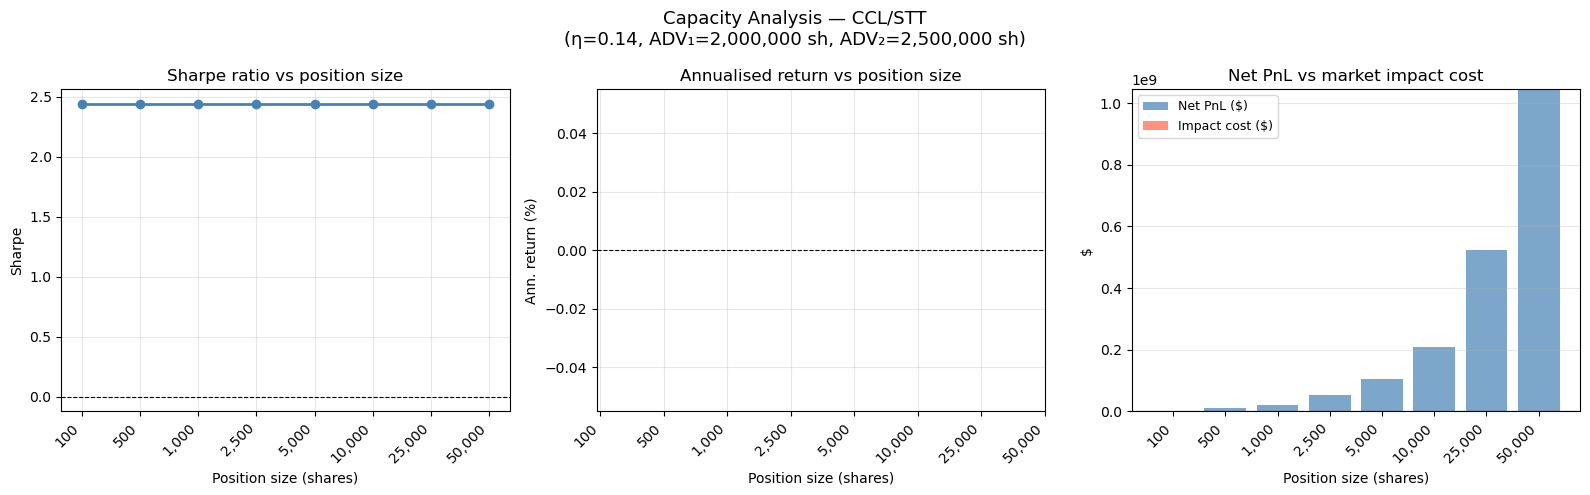


Max viable position size: 50,000 shares (2.50% of ADV) — Sharpe 2.44


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Capacity Analysis — {ticker1}/{ticker2}\n"
    f"(η={ETA}, ADV₁={ADV_1:,} sh, ADV₂={ADV_2:,} sh)",
    fontsize=13,
)

sizes = capacity_df.index.tolist()
x = range(len(sizes))
xlabels = [f"{s:,}" for s in sizes]

# ── Left: Sharpe vs position size ─────────────────────────────────────────
ax = axes[0]
ax.plot(x, capacity_df["sharpe"], "o-", color="steelblue", lw=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Sharpe ratio vs position size")
ax.set_xlabel("Position size (shares)")
ax.set_ylabel("Sharpe")
ax.set_xticks(list(x))
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.grid(True, alpha=0.3)

# ── Middle: Annualised return vs position size ─────────────────────────────
ax = axes[1]
ax.plot(x, capacity_df["ann_return_%"], "o-", color="darkorange", lw=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Annualised return vs position size")
ax.set_xlabel("Position size (shares)")
ax.set_ylabel("Ann. return (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.grid(True, alpha=0.3)

# ── Right: Impact cost vs net PnL ─────────────────────────────────────────
ax = axes[2]
ax.bar(x, capacity_df["net_pnl_$"], label="Net PnL ($)", color="steelblue", alpha=0.7)
ax.bar(
    x, -capacity_df["impact_cost_$"],
    bottom=capacity_df["net_pnl_$"],
    label="Impact cost ($)", color="tomato", alpha=0.7,
)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Net PnL vs market impact cost")
ax.set_xlabel("Position size (shares)")
ax.set_ylabel("$")
ax.set_xticks(list(x))
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── Break-even participation rate ─────────────────────────────────────────
positive_sharpe = capacity_df[capacity_df["sharpe"] > 0]
if len(positive_sharpe) > 0:
    max_viable = positive_sharpe.index.max()
    pct = capacity_df.loc[max_viable, "participation_%"]
    print(f"\nMax viable position size: {max_viable:,} shares "
          f"({pct:.2f}% of ADV) — Sharpe {capacity_df.loc[max_viable,'sharpe']:.2f}")
else:
    print("\nStrategy has negative Sharpe even at smallest test size — "
          "check in-sample signals.")


# 10. Circuit Breaker — Risk Controls on Trading Signals

Even a well-calibrated pairs strategy can be hit by events that break its core
assumptions: a sudden spread blow-out (structural break, news shock, liquidity
crisis) or a prolonged losing streak that exceeds a portfolio manager's drawdown
tolerance.  A **circuit breaker** is a risk overlay that monitors these conditions
in real time and *flattens all open positions* when a threshold is breached, then
imposes a mandatory cooling-off period before re-entry is allowed.

Two triggers are implemented here as a post-processor on the signals DataFrame:

| Trigger | Logic |
|---------|-------|
| **Z-score blow-out** | If `|z| > z_halt`, force flat for `cb_cooldown_bars` bars; optionally wait until `|z| < z_reentry` before re-entry |
| **Rolling drawdown** | Shadow-evaluate the equity curve; if the rolling drawdown over `drawdown_window_bars` exceeds `max_drawdown_pct × capital_base`, force flat for `halt_bars` bars |

> **Design note:** `apply_circuit_breaker` is a *standalone post-processor* —
> it does not re-run the Kalman filter or signal generation.  The caller receives
> modified signals and is responsible for re-evaluating them.  This makes the
> circuit breaker fully composable with any upstream signal generator.

## 10.1 Apply the circuit breaker to in-sample signals

In [37]:
from pairs import apply_circuit_breaker

# ── Configure both triggers ───────────────────────────────────────────────────
# z_halt = z_stop used in generate_pair_signals (same blow-out threshold)
# cb_cooldown_bars = 10 trading days (~2 weeks)
# z_reentry = z_entry: only allow re-entry once z has calmed back down
# max_drawdown_pct = 5 % of capital_base over a 63-bar rolling window
# halt_bars = 20 trading days (~1 month) after a drawdown breach

signals_cb, audit = apply_circuit_breaker(
    signals,          # output of generate_pair_signals (in-sample)
    df_pair,          # same df_pair used for signal generation
    z_halt=4.0,
    cb_cooldown_bars=10,
    z_reentry=2.0,
    max_drawdown_pct=0.05,
    drawdown_window_bars=63,
    halt_bars=20,
    capital_base=10_000.0,
    evaluate_kwargs=dict(cost_bps=1, borrow_bps_per_year=50, days_per_year=252),
)

n_halted = int(audit['n_halted_bars'].sum())
pct_halted = n_halted / len(signals) * 100
print(f"Halt windows triggered : {len(audit)}")
print(f"Total halted bars      : {n_halted} / {len(signals)} ({pct_halted:.1f}%)")
print()
if len(audit):
    print('Trigger breakdown:')
    print(audit['trigger_type'].value_counts().to_string())

Halt windows triggered : 9
Total halted bars      : 153 / 1508 (10.1%)

Trigger breakdown:
trigger_type
z_halt    9


## 10.2 Evaluate circuit-breaker-modified signals

In [38]:
daily_cb, trades_cb, summary_cb = evaluate_pair_signals(
    df_pair, signals_cb,
    cost_bps=1,
    fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50,
    days_per_year=252, bars_per_year=252,
)

print('=== In-sample performance WITH circuit breaker ===')
for k in ['sharpe', 'ann_return', 'max_drawdown_pct', 'n_trades', 'hit_rate', 'profit_factor']:
    v = summary_cb.get(k, float('nan'))
    if k == 'ann_return':
        print(f'  {k:25s}: {v*100:7.2f} %')
    elif k == 'max_drawdown_pct':
        print(f'  {k:25s}: {v*100:7.2f} %')
    else:
        print(f'  {k:25s}: {v:7.3f}')

=== In-sample performance WITH circuit breaker ===
  sharpe                   :   2.430
  ann_return               :   32.32 %
  max_drawdown_pct         :    2.68 %
  n_trades                 :  70.000
  hit_rate                 :   0.914
  profit_factor            :  42.121


## 10.3 Equity curve — baseline vs circuit breaker

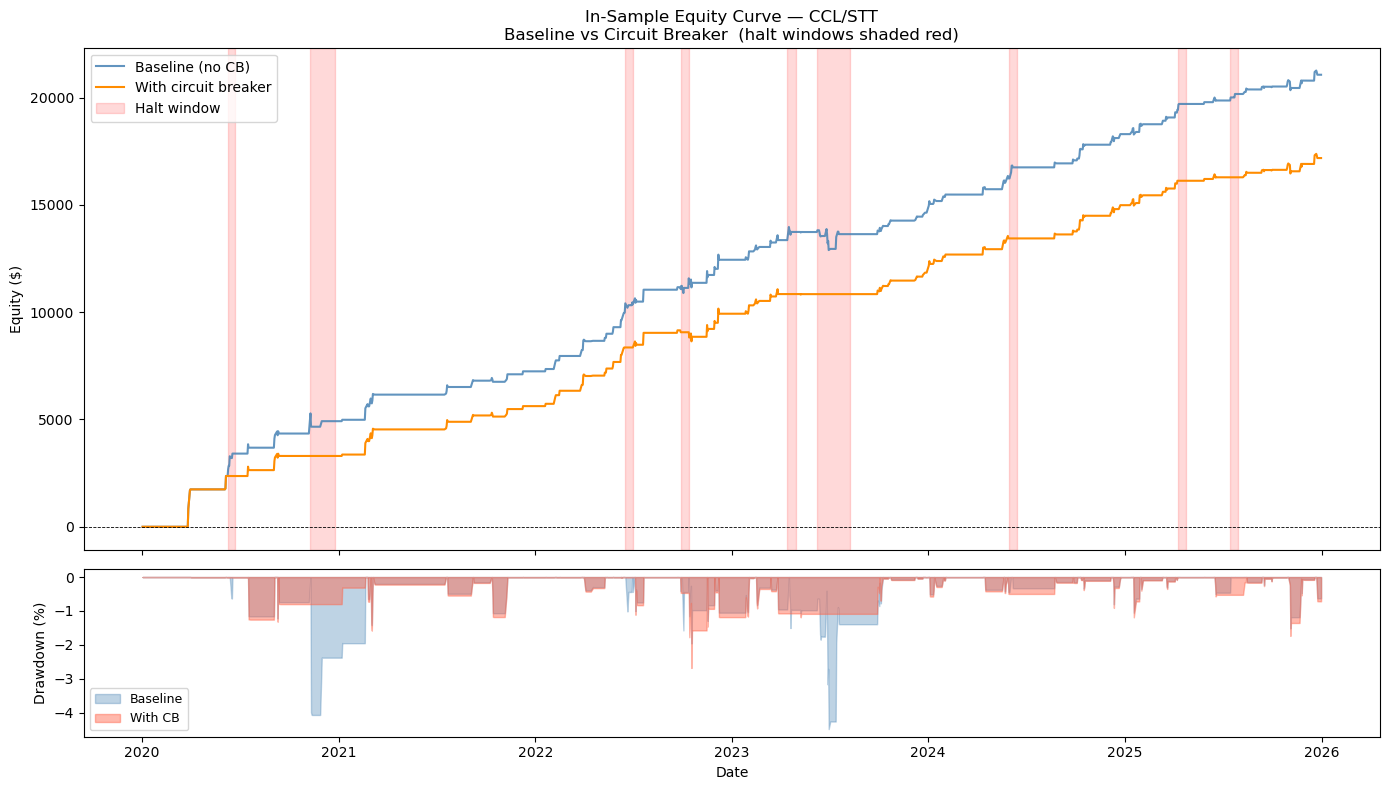

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# ── Equity curves ────────────────────────────────────────────────────────────
ax1.plot(daily_tr.index, daily_tr['equity'],
         color='steelblue', lw=1.5, alpha=0.85, label='Baseline (no CB)')
ax1.plot(daily_cb.index, daily_cb['equity'],
         color='darkorange', lw=1.5, label='With circuit breaker')

# ── Shade halt windows ───────────────────────────────────────────────────────
for i, row in audit.iterrows():
    ax1.axvspan(
        row['halt_start'], row['halt_end'],
        alpha=0.15, color='red',
        label='_nolegend_' if i > 0 else 'Halt window',
    )

ax1.axhline(0, color='black', lw=0.6, ls='--')
ax1.set_ylabel('Equity ($)')
ax1.set_title(
    f'In-Sample Equity Curve — {ticker1}/{ticker2}\n'
    f'Baseline vs Circuit Breaker  (halt windows shaded red)',
    fontsize=12,
)
ax1.legend(fontsize=10)

# ── Drawdown comparison ──────────────────────────────────────────────────────
ax2.fill_between(daily_tr.index, daily_tr['drawdown_pct'] * 100, 0,
                 alpha=0.35, color='steelblue', label='Baseline')
ax2.fill_between(daily_cb.index, daily_cb['drawdown_pct'] * 100, 0,
                 alpha=0.45, color='tomato', label='With CB')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10.4 Circuit breaker audit log

In [40]:
if len(audit) == 0:
    print('No circuit breaker events fired on this pair/period.')
else:
    display_audit = audit.copy()
    display_audit['halt_start'] = display_audit['halt_start'].dt.strftime('%Y-%m-%d')
    display_audit['halt_end']   = display_audit['halt_end'].dt.strftime('%Y-%m-%d')
    display_audit['z_at_trigger']     = display_audit['z_at_trigger'].map(
        lambda v: f'{v:.2f}' if v == v else 'n/a')
    display_audit['dd_pct_at_trigger'] = display_audit['dd_pct_at_trigger'].map(
        lambda v: f'{v:.4f}' if v == v else 'n/a')
    print(display_audit.to_string(index=False))

trigger_type z_at_trigger dd_pct_at_trigger halt_start   halt_end  n_halted_bars
      z_halt         6.56               n/a 2020-06-08 2020-06-22             11
      z_halt         5.56               n/a 2020-11-09 2020-12-24             33
      z_halt         4.73               n/a 2022-06-16 2022-07-01             11
      z_halt         4.04               n/a 2022-09-29 2022-10-13             11
      z_halt         4.25               n/a 2023-04-14 2023-05-01             12
      z_halt         5.24               n/a 2023-06-09 2023-08-09             42
      z_halt         4.17               n/a 2024-05-31 2024-06-14             11
      z_halt         4.98               n/a 2025-04-09 2025-04-24             11
      z_halt         4.05               n/a 2025-07-15 2025-07-29             11


## 10.5 Performance comparison — baseline vs circuit breaker

In [41]:
metrics = ['sharpe', 'ann_return', 'max_drawdown_pct', 'n_trades', 'hit_rate', 'profit_factor']
labels  = ['Sharpe', 'Ann. Return', 'Max Drawdown', 'Trades', 'Hit Rate', 'Profit Factor']

comparison_cb = pd.DataFrame(
    {
        'Baseline':       pd.Series({k: summary_tr.get(k, float('nan')) for k in metrics}),
        'With CB':        pd.Series({k: summary_cb.get(k, float('nan')) for k in metrics}),
    },
    index=metrics,
)
# Convert returns and drawdown to %
for m in ['ann_return', 'max_drawdown_pct']:
    comparison_cb.loc[m] *= 100
comparison_cb.index = labels

print('=== IS Performance: Baseline vs Circuit Breaker ===')
print(comparison_cb.to_string(float_format='{:.3f}'.format))

=== IS Performance: Baseline vs Circuit Breaker ===
               Baseline  With CB
Sharpe            2.454    2.430
Ann. Return      40.690   32.316
Max Drawdown      4.486    2.682
Trades           86.000   70.000
Hit Rate          0.919    0.914
Profit Factor    20.594   42.121


## 10.6 Interpretation

The circuit breaker trades off **absolute return** for **drawdown resilience**:

- **Max drawdown** should be lower or equal with the CB active — the breaker
  prevents runaway losses by forcing early exit when the strategy starts
  behaving anomalously.
- **Trade count** will decrease because some entry signals fall inside halt
  windows.  The remaining trades should have similar or better quality (hit
  rate, profit factor).
- **Annualised return** may decrease modestly in-sample (the CB sometimes
  exits positions that would have recovered).  In a live crisis scenario the
  CB should significantly outperform the unconstrained strategy.

**Parameter guidance for production use:**

| Parameter | Conservative | Moderate | Aggressive |
|-----------|-------------|----------|------------|
| `z_halt` | 3.5 | 4.0 | 5.0 |
| `cb_cooldown_bars` | 15 | 10 | 5 |
| `z_reentry` | 1.5 | 2.0 | None |
| `max_drawdown_pct` | 0.03 | 0.05 | 0.10 |
| `halt_bars` | 30 | 20 | 10 |

> **Note on IS vs OOS calibration:** circuit breaker thresholds should be
> validated out-of-sample.  Thresholds that fire frequently in-sample will
> generate excessive false positives.  A practical rule of thumb is to set
> `z_halt` at or above the `z_stop` used in signal generation and
> `max_drawdown_pct` at 2–3× the expected single-trade loss.

## 11. Pair Correlation & Portfolio Diversification

When running multiple pairs simultaneously the **spread returns** of different pairs may be correlated — for example, two technology pairs driven by the same macro factor will both lose when that factor reverses. Holding many such pairs provides less diversification than it appears on a per-pair basis.

This section quantifies correlation across active pairs and derives diversification-aware capital weights.

| Step | What we compute | Why it matters |
|------|----------------|----------------|
| 11.1 | Cross-pair Δresid correlation matrix | Shows which pairs move together |
| 11.2 | Portfolio diversification score (1 / mean ‖ρ‖) | Single number: >3 = well diversified |
| 11.3 | Inverse-variance position weights | Reduces exposure to noisy pairs |

In [42]:
## 11.0 Build kf_results for portfolio analytics

# `states_tr` (defined in Section 3) is already the dict we need:
# it maps (ticker1, ticker2) → DataFrame with alpha, beta, y_hat, resid columns.
#
# For the portfolio functions (pair_return_correlations, suggest_position_weights,
# summarize_hedge_ratio_stability) we pass the full multi-pair dict.
# We also set pair_key to the single selected pair for the per-pair detail plots.

kf_results = states_tr          # Dict[Tuple[str,str], pd.DataFrame]
pair_key   = (ticker1, ticker2) # e.g. ("CCL", "EXPE") — the pair selected in Section 3.4

print(f"kf_results contains {len(kf_results)} pairs")
print(f"Selected pair for detail plots: {pair_key}")

kf_results contains 200 pairs
Selected pair for detail plots: ('CCL', 'STT')


In [43]:
## 11.1 Cross-pair spread-return correlation matrix

from pairs.stats.portfolio import pair_return_correlations

import seaborn as sns

# kf_results was defined in cell 11.0 (= states_tr, the multi-pair Kalman dict)
corr = pair_return_correlations(kf_results, method="pearson", min_overlap=30)

n = len(corr)
fig, ax = plt.subplots(figsize=(max(5, n), max(4, n - 1)))
mask = np.eye(n, dtype=bool)   # mask diagonal for visual clarity
sns.heatmap(
    corr,
    mask=mask,
    annot=(n <= 20),   # only annotate when small enough to read
    fmt=".2f",
    center=0, vmin=-1, vmax=1,
    cmap="RdBu_r",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Cross-pair spread-return correlations (Pearson, Δresid)")
plt.tight_layout()
plt.show()
print(f"\n{n}×{n} correlation matrix — preview (top-left 10×10):")
print(corr.iloc[:10, :10].round(3).to_string())


200×200 correlation matrix — preview (top-left 10×10):
           NCLH/TRMB  NCLH/WDAY  NCLH/NSC  NCLH/TXN  NCLH/PDD  CCL/TTWO  NCLH/SBUX  NCLH/NWSA  NCLH/SHOP  CCL/SHOP
NCLH/TRMB      1.000      0.770     0.769     0.798     0.698     0.544      0.739      0.622      0.727     0.536
NCLH/WDAY      0.770      1.000     0.791     0.846     0.848     0.734      0.802      0.607      0.867     0.710
NCLH/NSC       0.769      0.791     1.000     0.823     0.743     0.631      0.797      0.656      0.732     0.563
NCLH/TXN       0.798      0.846     0.823     1.000     0.789     0.664      0.812      0.651      0.788     0.620
NCLH/PDD       0.698      0.848     0.743     0.789     1.000     0.788      0.753      0.546      0.835     0.703
CCL/TTWO       0.544      0.734     0.631     0.664     0.788     1.000      0.637      0.464      0.708     0.838
NCLH/SBUX      0.739      0.802     0.797     0.812     0.753     0.637      1.000      0.621      0.754     0.594
NCLH/NWSA      0.622    

In [44]:
## 11.2 Portfolio diversification score

from pairs.stats.portfolio import portfolio_diversification_score

score = portfolio_diversification_score(corr)
print(f"Portfolio diversification score: {score:.2f}")
if np.isnan(score):
    print("  (only one pair — no cross-pair correlation to measure)")
elif score == float("inf"):
    print("  Interpretation: pairs are perfectly uncorrelated — maximum diversification")
elif score >= 5:
    print("  Interpretation: excellent diversification (score ≥ 5)")
elif score >= 3:
    print("  Interpretation: good diversification (score ≥ 3)")
elif score >= 2:
    print("  Interpretation: moderate diversification — consider adding uncorrelated pairs")
else:
    print("  Interpretation: low diversification — pairs are highly correlated; "
          "consider reducing exposure or selecting more independent pairs")

Portfolio diversification score: 1.70
  Interpretation: low diversification — pairs are highly correlated; consider reducing exposure or selecting more independent pairs


In [45]:
## 11.3 Inverse-variance position weights

from pairs.stats.portfolio import suggest_position_weights

weights = suggest_position_weights(
    kf_results,
    corr,
    method="inv_var",    # weight ∝ 1 / Var(Δresid)
    max_weight=0.40,     # no single pair > 40% of capital
)

print("Suggested capital allocation (inverse-variance weighted):")
print(weights[["pair", "resid_var", "weight", "suggested_capital_pct"]].to_string(index=False))
print(f"\nWeights sum to: {weights['weight'].sum():.6f}")
print("\nTo apply: pass suggested_capital_pct × total_capital as capital_per_pair "
      "when calling generate_pair_signals for each pair.")

Suggested capital allocation (inverse-variance weighted):
     pair  resid_var   weight  suggested_capital_pct
 CCL/CPAY   0.104527 0.010726               1.072622
  CCL/HON   0.110338 0.010161               1.016132
  CCL/ECL   0.111707 0.010037               1.003680
  CCL/ITW   0.115693 0.009691               0.969100
NCLH/PAYC   0.119290 0.009399               0.939881
  CCL/ROK   0.119333 0.009395               0.939542
NCLH/SBAC   0.121167 0.009253               0.925318
NCLH/ZBRA   0.122715 0.009136               0.913647
  CCL/DLR   0.124138 0.009032               0.903172
  CCL/TDY   0.124864 0.008979               0.897923
  CCL/NSC   0.128067 0.008755               0.875468
NCLH/VRSN   0.132918 0.008435               0.843516
 CCL/EQIX   0.133232 0.008415               0.841524
 NCLH/ROK   0.134440 0.008340               0.833967
  CCL/TYL   0.134979 0.008306               0.830637
NCLH/PYPL   0.137179 0.008173               0.817311
  CCL/CRM   0.140858 0.007960            

## 11.4 Applying the weights in practice

The weights table above provides a principled starting point for capital allocation.

**Workflow:**
```python
total_capital = 100_000   # total strategy capital

for (k1, k2), row in weights.set_index("pair").iterrows():
    capital_per_pair = total_capital * row["weight"]
    signals = generate_pair_signals(
        df_pair[(k1, k2)],
        capital_per_pair=capital_per_pair,
        ...
    )
```

**Caveats to keep in mind:**

| Issue | Mitigation |
|-------|-----------|
| Correlation is estimated in-sample and may not hold OOS | Re-compute on a rolling basis (e.g., each month) |
| Inverse-variance ignores the off-diagonal structure (covariance) | Use minimum-variance portfolio with the full covariance matrix for a more precise allocation |
| `max_weight` cap is heuristic | Set based on risk limits, not just diversification math |
| Pairs with very low spread variance get very high weight | Add a minimum-weight floor if desired |

## 12. Hedge Ratio Stability Tests

The Kalman filter continuously updates the hedge ratio β to track the evolving relationship between the two legs. But if β undergoes a **structural shift** — caused by a change in business model, index composition, regulatory change, or regime break — the spread no longer mean-reverts to zero and any open position will not converge.

Two complementary tests detect β instability:

| Test | What it detects | Statistic |
|------|----------------|-----------|
| **CUSUM** | Level shifts (sudden β jump) | max\|S_t\| / √T vs. 1.36 (α=5%) |
| **Rolling drift** | Gradual volatility increase | max(σ_roll / σ_global) vs. threshold |

Both tests use only the Kalman β series — no additional data needed.

In [46]:
## 12.1 Stability summary across all pairs

from pairs.stats.stability import summarize_hedge_ratio_stability

stab = summarize_hedge_ratio_stability(
    kf_results,
    cusum_alpha=0.05,
    roll_window=63,          # ~1 quarter rolling window
    roll_threshold_sigma=2.0,
    min_obs=30,
)

print(f"Pairs tested: {len(stab)}")
n_unstable = (~stab["overall_stable"]).sum()
print(f"Unstable pairs (flagged by at least one test): {n_unstable}")
print()
print(stab.to_string())

Pairs tested: 200
Unstable pairs (flagged by at least one test): 200

                 cusum_stat  cusum_critical  cusum_stable  roll_max_ratio  roll_stable  n_flagged_bars  overall_stable
ticker1 ticker2                                                                                                       
AVGO    RL        17.125892            1.36         False        0.342721         True               0           False
BKNG    MA        16.690479            1.36         False        0.439054         True               0           False
CTRA    VTRS      16.293153            1.36         False        0.686425         True               0           False
NCLH    OXY       16.066455            1.36         False        0.910945         True               0           False
        SLB       15.801011            1.36         False        0.909235         True               0           False
        SPG       15.522068            1.36         False        1.403007         True           

Pair: ('CCL', 'STT')
CUSUM statistic:  10.9973
Critical value:   1.36 (α = 0.05)
Hedge ratio stable? NO — flagged as unstable


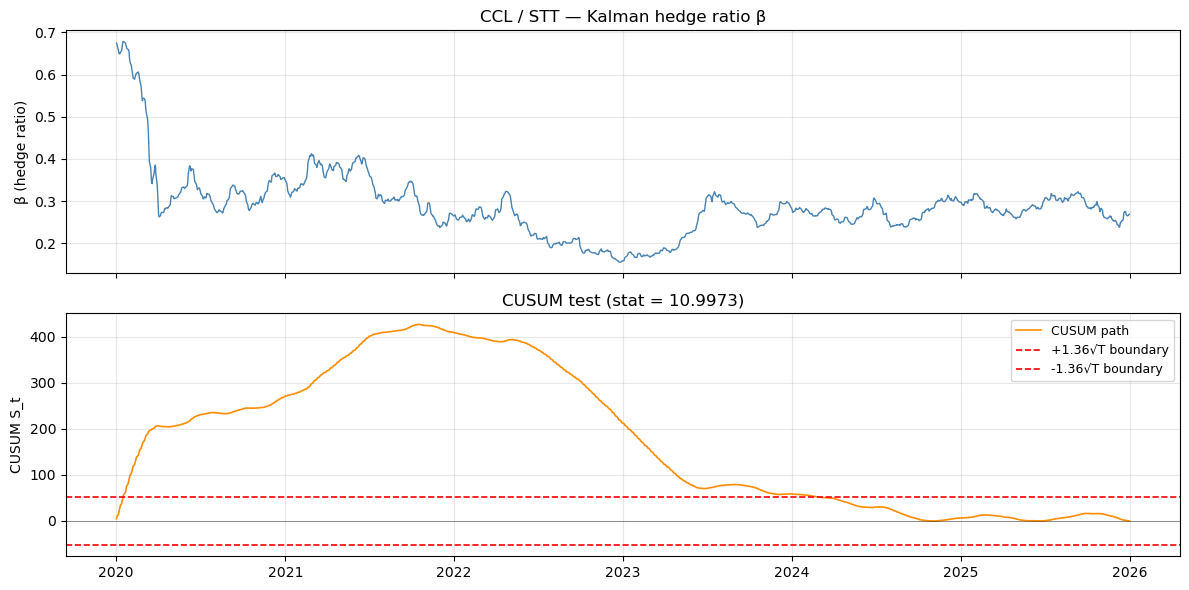

In [47]:
## 12.2 CUSUM test — detailed view for the selected pair

from pairs.stats.stability import cusum_beta_stability

# Use the pair selected earlier in the notebook
beta_series = kf_results[pair_key]["beta"].dropna()
cusum_result = cusum_beta_stability(beta_series, alpha=0.05)

print(f"Pair: {pair_key}")
print(f"CUSUM statistic:  {cusum_result['cusum_stat']:.4f}")
print(f"Critical value:   {cusum_result['critical_val']} (α = {cusum_result['alpha']})")
print(f"Hedge ratio stable? {'Yes' if cusum_result['is_stable'] else 'NO — flagged as unstable'}")

# Plot CUSUM path with ±crit·√T boundary bands
T = len(beta_series)
crit_band = cusum_result["critical_val"] * np.sqrt(T)
S = cusum_result["cusum_series"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: raw beta series
axes[0].plot(beta_series.index, beta_series.values, color="steelblue", linewidth=1)
axes[0].set_ylabel("β (hedge ratio)")
axes[0].set_title(f"{pair_key[0]} / {pair_key[1]} — Kalman hedge ratio β")
axes[0].grid(True, alpha=0.3)

# Bottom: CUSUM path with bands
axes[1].plot(S.index, S.values, color="darkorange", linewidth=1.2, label="CUSUM path")
axes[1].axhline(+crit_band, color="red", linestyle="--", linewidth=1.2, label=f"+{cusum_result['critical_val']}√T boundary")
axes[1].axhline(-crit_band, color="red", linestyle="--", linewidth=1.2, label=f"-{cusum_result['critical_val']}√T boundary")
axes[1].axhline(0, color="black", linewidth=0.7, alpha=0.4)
axes[1].set_ylabel("CUSUM S_t")
axes[1].set_title(f"CUSUM test (stat = {cusum_result['cusum_stat']:.4f})")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Max rolling std ratio:  1.8125
Threshold (sigma):      2.0
Stable?                 Yes
Flagged bars:           0


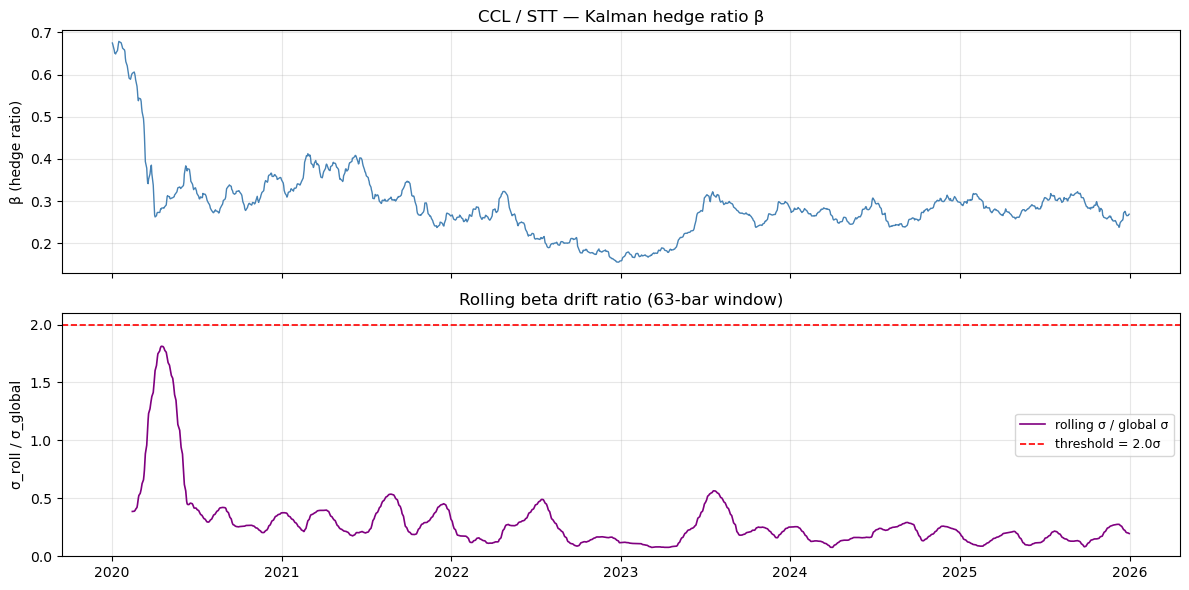

In [48]:
## 12.3 Rolling drift test — detailed view for the selected pair

from pairs.stats.stability import rolling_beta_drift

drift_result = rolling_beta_drift(beta_series, window=63, threshold_sigma=2.0)

print(f"Max rolling std ratio:  {drift_result['max_roll_std_ratio']:.4f}")
print(f"Threshold (sigma):      {drift_result['threshold_sigma']}")
print(f"Stable?                 {'Yes' if drift_result['is_stable'] else 'NO — β volatility burst detected'}")
print(f"Flagged bars:           {len(drift_result['flagged_dates'])}")
if len(drift_result["flagged_dates"]) > 0:
    print(f"  First flagged: {drift_result['flagged_dates'][0].date()}")
    print(f"  Last  flagged: {drift_result['flagged_dates'][-1].date()}")

roll_ratio = drift_result["roll_std_series"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: raw beta series
axes[0].plot(beta_series.index, beta_series.values, color="steelblue", linewidth=1)
axes[0].set_ylabel("β (hedge ratio)")
axes[0].set_title(f"{pair_key[0]} / {pair_key[1]} — Kalman hedge ratio β")
axes[0].grid(True, alpha=0.3)

# Bottom: rolling std ratio
axes[1].plot(roll_ratio.index, roll_ratio.values, color="purple", linewidth=1.2, label="rolling σ / global σ")
axes[1].axhline(drift_result["threshold_sigma"], color="red", linestyle="--", linewidth=1.2,
                label=f"threshold = {drift_result['threshold_sigma']}σ")

# Shade flagged regions
flagged = roll_ratio > drift_result["threshold_sigma"]
if flagged.any():
    axes[1].fill_between(roll_ratio.index, 0, roll_ratio.values,
                         where=flagged.fillna(False), color="red", alpha=0.2, label="Flagged bars")

axes[1].set_ylabel("σ_roll / σ_global")
axes[1].set_title("Rolling beta drift ratio (63-bar window)")
axes[1].legend(fontsize=9)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12.4 Interpretation and next steps

### Reading the stability results

| overall_stable | cusum_stable | roll_stable | Interpretation |
|:-:|:-:|:-:|-|
| ✅ | ✅ | ✅ | β is well-behaved — proceed with confidence |
| ⚠️ | ✅ | ❌ | Gradual volatility increase — monitor closely; tighten the z_halt circuit breaker |
| ⚠️ | ❌ | ✅ | A level shift occurred — inspect the CUSUM plot; consider excluding OOS data before the shift |
| ❌ | ❌ | ❌ | Pair has structurally changed — likely cointegration has broken; exclude from live trading |

### Decision framework

**Action on flagged pairs:**
1. **Inspect** — plot the raw β series and CUSUM path to identify _when_ the shift happened
2. **Truncate** — if the shift occurred before the OOS window, consider re-fitting Kalman only on post-shift data
3. **Exclude** — if β shows persistent drift throughout the OOS period, remove the pair from the active universe
4. **Monitor** — for borderline cases, enable the `z_halt` circuit breaker with a tighter threshold (e.g., 3.5 instead of 4.0)

### Parameter guidance

| Parameter | Conservative | Moderate | Aggressive |
|-----------|-------------|---------|-----------|
| `cusum_alpha` | 0.01 (strict) | 0.05 | 0.10 |
| `roll_window` | 42 bars | 63 bars | 126 bars |
| `roll_threshold_sigma` | 1.5× | 2.0× | 3.0× |

Tighter parameters catch instability earlier but increase false positives on pairs with naturally volatile β (e.g., during earnings season).